# 1. Introduction
This project investigates the motion of the motion of a projectile using mathematical modelling and numerical simulation. Projectile motion is the curved path an object follows when it is launched into the air and moves under the influence of gravity, and subsequently air resistance/drag. The project begins with an ideal system in which the projectile is only moving under the influence of gravity, and later progressively introduces drag to investigate its effect on the motion. 

# 2. Assumptions
- The projectile is modelled as a point mass (zero-dimensional)
- Gravitational acceleration is constant and uniform
- The Earth is approximated as being flat
- Air resistance/drag is initially ignored
- The rotation of the Earth does not affect the path of the object

# 3. Ideal System
For simplicity, in this section, air resistance is ignored, and the projectile is moving only under the influence of gravity

## 3.1. Mathematical Model
First, we define $ x $ to be horizontal displacement, and $y$ to be vertical displacement. The projectile is initially stationary, but at time $t = 0$ it is launched with speed $u$ at an angle $\theta$ where $\theta$ is measured anti-clockwise from the surface.

The equation of the motion of a projectile in an ideal system is governed only by two equations:
$$
\begin{aligned}
\frac{\mathrm{d}^2y}{\mathrm{d}t^2} &= -g\\
\frac{\mathrm{d}^2x}{\mathrm{d}t^2} &= 0
\end{aligned}
$$

where $g \approx 9.81$.

### Velocity

The horizontal component of velocity, $v_x$ is constant because there is no force acting in this horizontal direction, thus the projectile has a constant horizontal velocity, that being the horizontal component of the initial launch speed, $u \cos{\theta}$. 
$$v_x = u \cos{\theta}$$

The vertical component of the velocity, $v_y$, at time $t$, changes linearly because of the constant downward acceleration of gravity. The component of velocity can be found by integrating the expression for the vertical acceleration, given the initial condition of vertical velocity being $u \sin{\theta}$
$$v_y = u \sin{\theta} - gt$$

### Displacement

By integrating the horizontal velocity, given the initial condition $x(0) = 0$, we get

$$\boxed{x(t) = t u \cos{\theta}}$$

By integrating the vertical velocity, given the initial condition $y(0) = 0$,

$$\boxed{y(t) = t u \sin{\theta} - \frac{1}{2} g t^2}$$


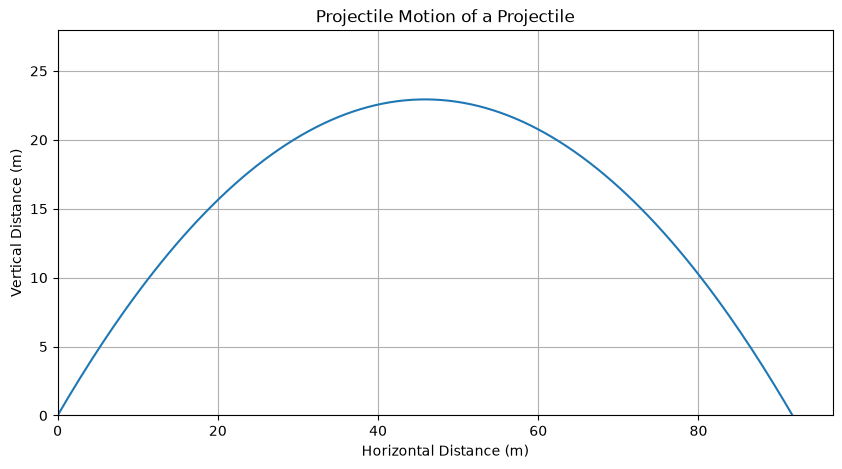

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Plotting the motion of a projectile under the influence of gravity
g = 9.81  # Acceleration due to gravity (m/s^2)
u = 30  # Initial velocity (m/s)
def ideal_model_data(theta):
    
    theta_rad = np.radians(theta)  # Convert angle to radians
    t_max = 2 * u * np.sin(theta_rad) / g  # Time of flight
    t = np.linspace(0, t_max, num=200)  # Time of flight
    x = u * np.cos(theta_rad) * t
    y = u * np.sin(theta_rad) * t - 0.5 * g * t**2
    vx = u * np.cos(theta_rad)
    vy = u * np.sin(theta_rad) - (g * t)
    
    return (t,x,y,vx,vy)

t_i = ideal_model_data(45)[0]
x_i = ideal_model_data(45)[1]
y_i = ideal_model_data(45)[2]
vx_i =ideal_model_data(45)[3]
vy_i =ideal_model_data(45)[4]

# Plotting the trajectory
plt.figure(figsize=(10, 5))
plt.plot(x_i, y_i)
plt.title('Projectile Motion of a Projectile')
plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Vertical Distance (m)')
plt.xlim(0, max(x_i) + 5)
plt.ylim(0, max(y_i) + 5)
plt.grid()
plt.show()

### Theoretical Range
The _range_ of the motion is the horizontal distance the projectile travels until it reaches the same vertical height at which it was launched. Since we define $y(0)=0$, there exists a value $t_0$ such that $y(t_0) = 0$. 

$t_0$ represents the time of flight. 

This value is a root of the equation $$t u \sin{\theta} - \frac{1}{2} g t^2  = 0$$

This equation has roots $t = 0$ and $t = \frac{ 2 u \sin{\theta} }{g}$.

$t =0 $ is a trivial solution. 

$$t_0 = \frac{ 2 u \sin{\theta} }{g}$$

The theoretical range of the projectile will be $$x(t_0) = u \cos{\theta} \cdot \frac{ 2 u \sin{\theta} }{g} = \frac{u^2 \sin(2\theta)}{g}$$

### Maximum Height
The maximum height the projectile reaches occurs when the vertical displacement stops increasing and starts decreasing downward. 
$$\frac{\mathrm{d}y(t)}{\mathrm{d}t} = 0$$
or rather
$$v_y(t_h) = u \sin{\theta} - gt_h = 0$$
where $t_h$ is the time at which the projectile reaches maximum height.
The solution is $$t_h = \frac{u \sin{\theta}}{g}$$

Therefore, the maximum height is 
$$y(t_h) = t_h u \sin{\theta} - \frac{1}{2} g {t_h}^2  = \frac{u^2 {\sin}^2{\theta} }{2g}$$


In [2]:
theta = np.radians(45)
R_ideal = u ** 2 * np.sin(2 * theta) / g
t_i_0 = 2 * u * np.sin(theta) / g
y_i_max = u ** 2 * (np.sin(theta)) **2 / (2 * g)

print("Below are values associated with the projectile in an ideal case")
print("The Range of  the Projectile is " + str(round(R_ideal, 1)) + "m")
print("The Time of Flight is " + str(round(t_i_0,1)) + "s")
print("The Maximum Height Achieved is " + str(round(y_i_max,1))+ "m")

Below are values associated with the projectile in an ideal case
The Range of  the Projectile is 91.7m
The Time of Flight is 4.3s
The Maximum Height Achieved is 22.9m


## 3.2. Animation (Ideal)

In [3]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# Points of motion

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))

ax.set(xlabel='Horizontal Distance (m)', ylabel='Vertical Distance (m)')
ax.set_xlim(min(x_i), math.ceil((1.05 * max(x_i))/10) * 10)
ax.set_ylim(min(y_i), math.ceil((1.05 * max(y_i))/10) * 10)
ax.set_aspect('equal')
ax.grid()
ax.set_title("Projectile Motion")
# Projectile
point, = ax.plot([], [], 'ro', markersize=8, label='Projectile')

# Trajectory
trajectory, = ax.plot([], [],color='blue', lw=2)

def update(n):
    point.set_data([x_i[n]], [y_i[n]])
    trajectory.set_data(x_i[:n+1], y_i[:n+1])
    return point, trajectory

ani = FuncAnimation(
    fig,
    update,
    frames=len(t_i),
    interval=20,
    blit=True
)

plt.close(fig)

# Save GIF
ani.save("projectile_animation.gif", writer="pillow", fps=30)

When varying launch velocity, an increase by a factor of two in the launch velocity corresponds to an increase by the square of that factor for the range of the projectile because $R \propto u^2$

## 3.3. Numerical Method (Euler's Method)
Euler's Method approximates the solution to a differential equation by taking small steps along the tangent to the solution curve. Given an initial condition $y_0$ at $t_0$, and knowing the derivative $y'(t)$, the value of $y$ at the next time step can be approximated using:
$$y_{n+1} = y_n + \Delta t \times y'(t_n)$$
where $\Delta t$ is the time step between successive approximations. 

A smaller value of $\Delta t$ leads to a more accurate approximation of the solution to the differential equation.

Euler's Method says that 
$$
y_{n+1} = y_n + \Delta t \times y'(t_n)
$$

By Taylor Expansion, the exact value should be 
$$
y_{n+1} = y_n + \Delta t \times y'(t_n) +\frac{y''(t_n)}{2!}(\Delta t)^2  + ...
$$


This leaves out the terms behind which are proportional to powers of $\Delta t$. 

The error is $\frac{y''(t_n)}{2!}(\Delta t)^2  + ...$

Therefore, by choosing smaller values of $\Delta t$, the error gets smaller.



For the motion of the projectile, the equations of motion can therefore be written as two sets of first order differential equations.
$$
\begin{aligned}
\frac{\mathrm{d}x}{\mathrm{d}t} &= v_x\\
\frac{\mathrm{d}y}{\mathrm{d}t} &= v_y
\end{aligned}
$$

$$
\begin{aligned}
\frac{\mathrm{d}v_x}{\mathrm{d}t} &= 0\\
\frac{\mathrm{d}v_y}{\mathrm{d}t} &= -g
\end{aligned}$$

Using Euler's Method: 
$$
\begin{aligned}
x_{n+1} &= x_n + \Delta t \times v_x\\
{v_x}_{n+1} &= {v_x}_{n} + \Delta t \times 0
\end{aligned}
$$

$$
\begin{aligned}
y_{n+1} &= y_n + \Delta t \times v_y\\
{v_y}_{n+1} &= {v_y}_{n} + \Delta t \times -g
\end{aligned}
$$

Below is the graph of the projectile motion using different levels of accuracy.

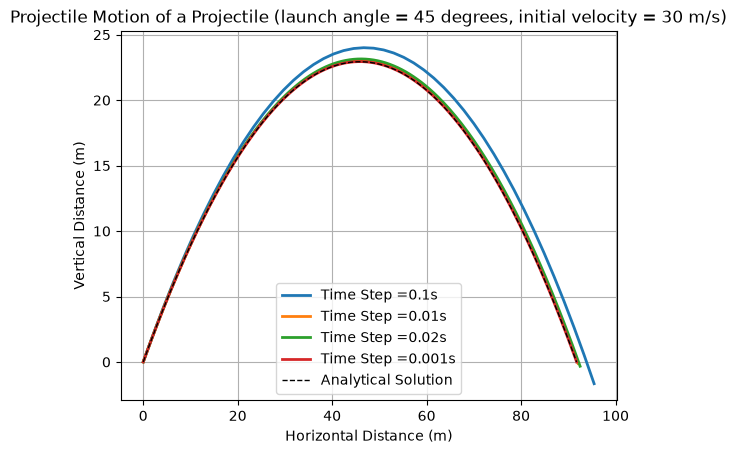

In [4]:
def numerical_solution(dt):
    theta = np.radians(45)  # Launch angle in radians
    v0 = 30  # Initial velocity (m/s)
    g = 9.81  # Acceleration due to gravity (m/s^2)
    x = 0
    y = 0
    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)

    xt = [x]
    yt = [y]
    vxt = [vx]
    vyt = [vy]
    t = [0]

    while y >= 0:

        # Euler updates
        x = x + vx * dt
        y = y + vy * dt
        vx = vx
        vy = vy - g * dt

        # Store values
        xt.append(x)
        yt.append(y)
        vxt.append(vx)
        vyt.append(vy)
        t.append(t[-1] + dt)
    plt.plot(xt, yt, label ="Time Step =" + str(dt) + "s", lw=2)

numerical_solution(0.1)  # dt = 0.1 s
numerical_solution(0.01)  # dt = 0.01 s
numerical_solution(0.02) # dt = 0.02 s
numerical_solution(0.001)  # dt = 0.001 s 
plt.plot(x_i, y_i, label ="Analytical Solution", color='black', lw=1, ls='--')
plt.title('Projectile Motion of a Projectile (launch angle = 45 degrees, initial velocity = 30 m/s)')
plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Vertical Distance (m)')
plt.grid()
plt.legend()
plt.show()

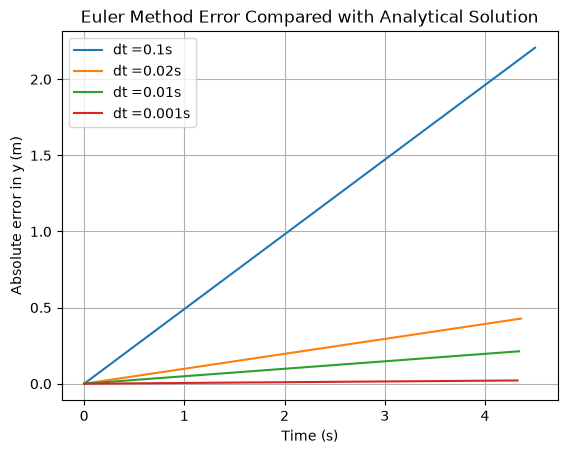

In [5]:
theta = np.radians(45)
t_flight = 2 * u * np.sin(theta) / g
time_steps = [0.1, 0.01, 0.001]

def solution_difference(dt):
    theta = np.radians(45)  # Launch angle in radians
    v0 = 30  # Initial velocity (m/s)
    g = 9.81  # Acceleration due to gravity (m/s^2)
    x = 0
    y = 0
    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)

    xt = [x]
    yt = [y]
    vxt = [vx]
    vyt = [vy]
    t = [0]

    while y >= 0:

        # Euler updates
        x = x + vx * dt
        y = y + vy * dt
        vx = vx
        vy = vy - g * dt

        # Store values
        xt.append(x)
        yt.append(y)
        vxt.append(vx)
        vyt.append(vy)
        t.append(t[-1] + dt)

    y_exact = u * np.sin(theta) * np.array(t) - 0.5 * g * np.array(t)**2
    error = np.abs(np.array(yt) - y_exact)

    plt.plot(t, error, label="dt =" + str(dt) + "s")

solution_difference(0.1)  # dt = 0.1 s
solution_difference(0.02)  # dt = 0.02 s
solution_difference(0.01)  # dt = 0.01 s
solution_difference(0.001)  # dt = 0.001 s
plt.title("Euler Method Error Compared with Analytical Solution")
plt.xlabel("Time (s)")
plt.ylabel("Absolute error in y (m)")
plt.grid()
plt.legend()
plt.show()

Choosing a small time step such as 0.01s or 0.001s already yields an approximation indistinguishable from the exact numerical solution. Using Euler's Method and choosing a time step of 0.02s serves as a useful time step for approximations.

# 4. Linear Drag (Stokes' drag)
The projectile is treated as a point mass for its translational motion. Its rotational motion and orientation are neglected. For the drag models, its physical dimensions are represented by the cross-sectional area and characteristic length. 

Air resistance creates force that is always opposite in direction to the motion of the projectile. In this section, the magnitude of linear drag is modelled to be proportional to speed. The drag force itself is a vector directed opposite to the projectile's velocity. $$F_d \propto v$$
## 4.1. Equations of Motion
Stokes' Law states that the drag force of a small sphere moving through a fluid is given by the formula:
$$F_d = -6 \pi \mu R v$$
where
$\mu$ is the dynamic viscosity of the fluid, $R$ is the radius of the sphere, $v$ is velocity


By letting $k=6 \pi \mu R$, we have that $$F_d = -kv$$

### Equations of Motion
The equations of motion in the $x$ and $y$ directions are derived from Newton's Second Law.
#### Horizontal
In the $x$ direction, 
$$
\sum F = ma_x = -kv_x
$$

By setting $b=\frac{k}{m}$,

$$
\begin{aligned}
a_x &= -bv_x\\
\frac{\mathrm{d}v_x}{\mathrm{d}t} &= -bv_x
\end{aligned}
$$

where $b=\frac{6 \pi \mu R}{m}$


Given the initial condition that the launch speed is $u$ (horizontal component is $u\cos{\theta}$), this first order differential equation has solution 
$$
v_x = u \cos{\theta} e^{-bt}
\tag{1}
$$

By integrating $(1)$ and given the initial condition that $x(0) = 0$, 
$$\boxed{x(t)=\frac{u\cos{\theta}}{b}(1-e^{-bt})}$$

#### Vertical 
In the $y$ direction, 
$$\sum F = m a_y = -kv_y - mg$$

By setting
$b=\frac{k}{m}$,

$$
\begin{aligned}
a_y &= - bv_y - g \\
\frac{\mathrm{d}v_y}{\mathrm{d}t} &= -bv_y - g\\
\end{aligned}
$$

This gives the first order linear differential equation: 
$$\frac{\mathrm{d}v_y}{\mathrm{d}t} + bv_y = -g$$
Integrating Factor : $e^{\int{b}~\mathrm{d}t} = e^{bt}$

$$
\begin{aligned}
e^{bt}(\frac{\mathrm{d}v_y}{\mathrm{d}t} + bv_y) &= -g e^{bt}\\
(v_y e^{bt})' &= -g e^{bt}\\
v_y e^{bt} &= \int{-g e^{bt}\ \mathrm{d}t}\\
v_y e^{bt} &= -\frac{g}{b} e^{bt} + C\\
v_y &= -\frac{g}{b} + C e^{-bt}
\end{aligned}
$$

With initial condition that the launch speed is $u$ (vertical component is $u\sin{\theta}$), we have that
$$C = \frac{g}{b} + u\sin{\theta}$$
Therefore, 
$$
v_y = -\frac{g}{b} + (\frac{g}{b} + u\sin{\theta})e^{-bt}
\tag{2}
$$

By integrating $(2)$:

$$y(t) = -\frac{g}{b}t - \frac{1}{b} (\frac{g}{b}+u\sin{\theta}) e^{-bt}+D$$
With initial condition $y(0) = 0$, $D = \frac{1}{b}(\frac{g}{b}+u\sin{\theta})$

This leads to
$$\boxed{y(t) = -\frac{g}{b}t + \frac{1}{b}(\frac{g}{b}+u\sin{\theta})(1-e^{-bt})}$$


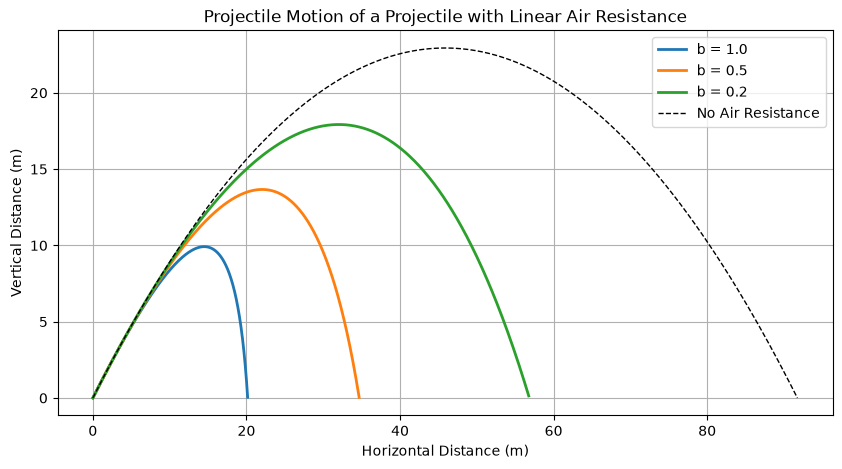

In [6]:
u = 30
g = 9.81
theta = np.radians(45)

def linear_drag_data(b):
    
    dt = 0.01

    t = 0

    xs = []
    ys = []

    while True:

        x = u * np.cos(theta) / b * (1 - np.exp(-b * t))

        y = (-g / b) * t + (1 / b) * (g / b + u * np.sin(theta)) * (1 - np.exp(-b * t))

        if y < 0:
            break

        xs.append(x)
        ys.append(y)

        t = t + dt
    return (t, xs, ys)

b1 = 1.0 
b2 = 0.5
b3 = 0.2
# Plotting the trajectory
plt.figure(figsize=(10, 5))
plt.plot(linear_drag_data(b1)[1], linear_drag_data(b1)[2], label = "b = " + str(b1), lw=2)
plt.plot(linear_drag_data(b2)[1], linear_drag_data(b2)[2], label = "b = " + str(b2), lw=2)
plt.plot(linear_drag_data(b3)[1], linear_drag_data(b3)[2], label = "b = " + str(b3), lw=2)
plt.plot(x_i, y_i, label ="No Air Resistance", color='black', lw=1, ls='--')
plt.title('Projectile Motion of a Projectile with Linear Air Resistance')
plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Vertical Distance (m)')
plt.grid()
plt.legend()
plt.show()

## 4.2. Maximum Height, Range and Time of Flight
Of these 3, only maximum height has an elementary expression.

### Maximum Height
Maximum height occurs at $t_{max}$ when
$$v_y = 0$$
Substituting $v_y = -\frac{g}{b} + (\frac{g}{b} + u\sin{\theta})e^{-bt}$,
$$-\frac{g}{b} + (\frac{g}{b} + u\sin{\theta})e^{-bt} =0$$
rearranging gives $$t_{max} = \frac{1}{b}\ln(1+\frac{ub}{g}\sin{\theta})$$

After simplification,
$$y(t_{max})= \frac{u}{b}\sin{\theta} + \frac{g}{b^2}\ln(1+\frac{ub}{g}\sin{\theta})$$

### Time of Flight
Flight time, $T$ must satisfy $y(T) = 0$ 
$$y(T) = -\frac{g}{b}T + \frac{1}{b}(\frac{g}{b}+u\sin{\theta})(1-e^{-bT}) = 0$$
This has no closed form solution in terms of elementary functions

### Range
Similar to Time of Flight, since $T$ has no elementary formula, $y(T)$ doesn't either.




## 4.3. Terminal Velocity 
Terminal velocity, $v_t$ is the constant velocity that an object approaches when the net force on the object is zero. Therefore, the drag force is equal in magnitude to the force of gravity (Newtonian physics). $F_d = mg$
$$
\begin{aligned}
kv_t &= mg\\
v_t &=\frac{mg}{k}
\end{aligned}
$$
where $k=6 \pi \mu R$ 

If $b=\frac{k}{m}$ 
$$v_t=\frac{g}{b}$$

During the initial stages of the flight, the projectile is flying along a curve. The direction of drag force isn't directly vertical. To achieve terminal velocity, the force of gravity and the drag force must be equal in magnitude and opposite in direction. As $t$ increases, drag causes the horizontal velocity,$v_x$ to approach zero. The projectile's motion therefore becomes increasingly vertical and downward. Consequently, the drag force becomes increasingly upward. As $t \rightarrow \infty$, the upward drag force balances the downward gravitational force. Net force will be zero, and a constant downward velocity known as the terminal velocity will be achieved.

## 4.4. Numerical Solution
$$\frac{\mathrm{d}v_x}{\mathrm{d}t} = -bv_x$$
$$\frac{\mathrm{d}v_y}{\mathrm{d}t}= - bv_y - g$$
Using Euler's Method we have
$$
\begin{aligned}
x_{n+1} &= x_n + \Delta t \times v_x\\
{v_x}_{n+1} &= {v_x}_{n} + \Delta t \times -b{v_x}_n
\end{aligned}
$$

$$
\begin{aligned}
y_{n+1} &= y_n + \Delta t \times v_y\\
{v_y}_{n+1} &= {v_y}_{n} + \Delta t \times (- b{v_y}_n - g)
\end{aligned}
$$

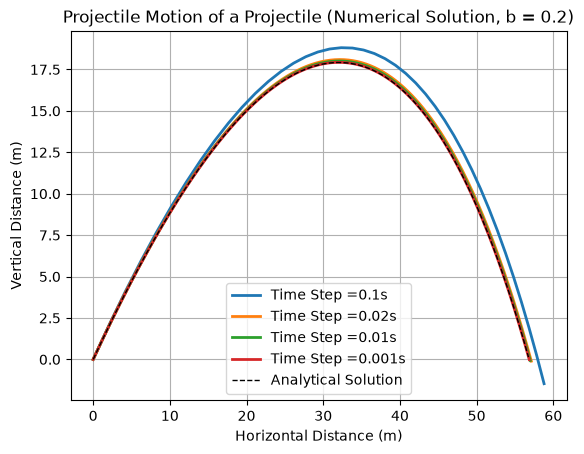

In [7]:
def numerical_linear_drag_data(b,dt):
    theta = np.radians(45)  # Launch angle in radians
    v0 = 30  # Initial velocity (m/s)
    g = 9.81  # Acceleration due to gravity (m/s^2)
    x = 0
    y = 0
    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)
    
    xt = [x]
    yt = [y]
    vxt = [vx]
    vyt = [vy]
    t = [0]
    vt=[v0]
    while y >= 0:

        # Euler updates
        x = x + vx * dt
        y = y + vy * dt
        vx = vx + (-b * vx) * dt
        vy = vy + (-b * vy - g) * dt
        v=np.sqrt((vx)**2 + (vy)**2)
        # Store values
        xt.append(x)
        yt.append(y)
        vxt.append(vx)
        vyt.append(vy)
        t.append(t[-1] + dt)
        vt.append(v)
    return (t, xt, yt, vxt, vyt,vt)


def numerical_linear_drag_plot(b, dt):
    plt.plot(numerical_linear_drag_data(b, dt)[1],
         numerical_linear_drag_data(b, dt)[2], 
         label ="Time Step =" + str(dt) + "s", lw=2)

b0 = 0.2
numerical_linear_drag_plot(b0,0.1)
numerical_linear_drag_plot(b0,0.02)
numerical_linear_drag_plot(b0,0.01)
numerical_linear_drag_plot(b0,0.001)
plt.plot(linear_drag_data(b0)[1], linear_drag_data(b0)[2], label = "Analytical Solution",lw = 1, ls = "--", color = "black")
plt.title('Projectile Motion of a Projectile (Numerical Solution, b = 0.2)')
plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Vertical Distance (m)')
plt.grid()
plt.legend()
plt.show()

## 4.5. Animation


In [8]:
u = 30
g = 9.81
theta = np.radians(45)

b1 = 0.2
b2 = 0.5
b3 = 1.0



# Calculate trajectories
xs1, ys1 = numerical_linear_drag_data(b1,0.05)[1],numerical_linear_drag_data(b1,0.05)[2]
xs2, ys2 = numerical_linear_drag_data(b2,0.05)[1],numerical_linear_drag_data(b2,0.05)[2]
xs3, ys3 = numerical_linear_drag_data(b3,0.05)[1],numerical_linear_drag_data(b3,0.05)[2]


fig, ax = plt.subplots(1, 3, figsize=(9, 3))

plt.subplots_adjust(wspace=0.6)

# Find overall limits
x_max = max(max(xs1), max(xs2), max(xs3))
y_max = max(max(ys1), max(ys2), max(ys3))


# Set up axes
for a in ax:
    a.set_xlim(0, x_max * 1.05)
    a.set_ylim(0, y_max * 1.05)
    a.set_aspect('equal')
    a.grid()
    a.set_xlabel("Horizontal Displacement")
    a.set_ylabel("Vertical Displacement")

# Titles
ax[0].set_title("b=" + str(b1))
ax[1].set_title("b=" + str(b2))
ax[2].set_title("b=" + str(b3))



# Projectile and trajectory for each subplot
projectile_1, = ax[0].plot([], [], 'o', color = "r")
trajectory_1, = ax[0].plot([], [], lw=2, color = "darkblue")

projectile_2, = ax[1].plot([], [], 'o', color = "r")
trajectory_2, = ax[1].plot([], [], lw=2, color = "darkblue")

projectile_3, = ax[2].plot([], [], 'o', color = "r")
trajectory_3, = ax[2].plot([], [], lw=2, color = "darkblue")


# Update function
def update(n):

    if n < len(xs1):
        projectile_1.set_data([xs1[n]], [ys1[n]])
        trajectory_1.set_data(xs1[:n+1], ys1[:n+1])

    if n < len(xs2):
        projectile_2.set_data([xs2[n]], [ys2[n]])
        trajectory_2.set_data(xs2[:n+1], ys2[:n+1])

    if n < len(xs3):
        projectile_3.set_data([xs3[n]], [ys3[n]])
        trajectory_3.set_data(xs3[:n+1], ys3[:n+1])

    return (
        projectile_1, trajectory_1,
        projectile_2, trajectory_2,
        projectile_3, trajectory_3
    )


# Number of frames
frames = max(len(xs1), len(xs2), len(xs3))


ani = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=20,
    blit=True
)


plt.close(fig)


ani.save(
    "projectile_animation_linear_damping.gif",
    writer="pillow",
    fps=30
)

# 5. Quadratic Drag (Newtonian Drag)
In this section, magnitude of drag force is modelled to be proportional to the speed squared, $F_d \propto v^2$. This is the most typical case of air resistance. 
The drag equation is as follows:
$$\vec{F_d} = - \frac{1}{2} c_d \rho A v \vec{v}$$
where $F_d$ is the drag force, $c_d$ is the drag coefficient, $\rho$ is the air density, $A$ is the cross-sectional area of the projectile, $v$ is the velocity of the projectile. 

(Note: $v = \sqrt{{v_x^2} + {v_y}^2}$, where $v_x$,$v_y$ are the horizontal and vertical components of velocity respectively)

Let $k = - \frac{1}{2} c_d \rho A$.
Then,
$$\vec{F_d} = -kv \vec{v}$$
It is therefore true that both necessary conditions are met: $|F_d| \propto v^2$ , and drag force acts opposite in direction to the direction of motion.

By resolving the forces to the horizontal and vertical axis:
$$
\begin{aligned}
{F_d}_x = m \frac{\mathrm{d}v_x}{\mathrm{d}t} &= -kvv_x\\
{F_d}_y = m \frac{\mathrm{d}v_y}{\mathrm{d}t} &= -mg - kvv_y
\end{aligned}
$$

Unfortunately, unlike the ideal case and the linear-drag case, it is impossible to find a closed form solution for the equations of motion. 


## 5.1. Numerical Solution
By again setting $b=\frac{k}{m}$, we have that 
$$
\begin{aligned}
\frac{\mathrm{d}v_x}{\mathrm{d}t} &= -bvv_x\\
\frac{\mathrm{d}v_y}{\mathrm{d}t} &= -g - bvv_y
\end{aligned}
$$
as well as
$$
\begin{aligned}
\frac{\mathrm{d}x}{\mathrm{d}t} &= v_x\\
\frac{\mathrm{d}y}{\mathrm{d}t} &= v_y
\end{aligned}
$$

By Euler's Method,

Horizontal Axis:
$$
\begin{aligned}
x_{n+1} &= x_n + {v_x}_n\Delta t\\
{v_x}_{n+1} &= {v_x}_n -b V_n{v_x}_{n} \Delta t
\end{aligned}
$$

Vertical Axis:
$$
\begin{aligned}
y_{n+1} &= y_n + {v_y}_n\Delta t\\
{v_y}_{n+1} &= {v_y}_n + (-g - b V_n{v_y}_{n}) \Delta t
\end{aligned}
$$

where $V_n = \sqrt{{{v_x}_n}^2 + {{v_y}_n}^2}$



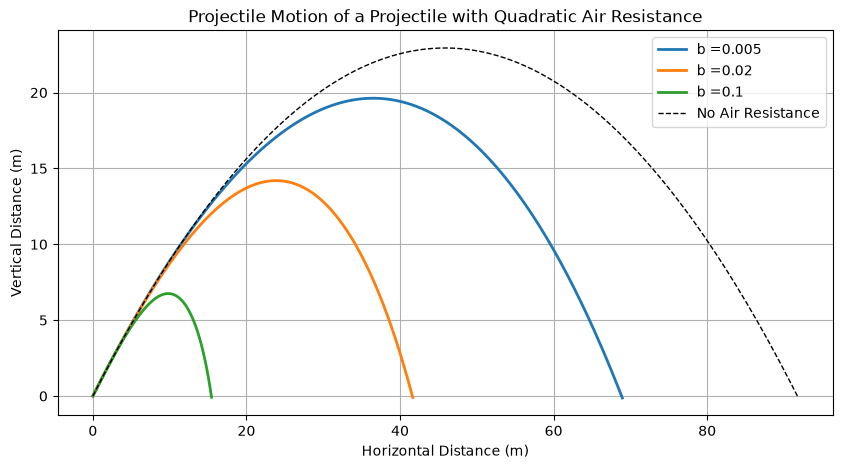

In [9]:
def quadratic_drag_data(b,dt):
    
    theta = np.radians(45)  # Launch angle in radians
    v0 = 30  # Initial velocity (m/s)
    g = 9.81  # Acceleration due to gravity (m/s^2)

    x = 0
    y = 0
    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)

    xt = [x]
    yt = [y]
    vxt = [vx]
    vyt = [vy]
    t = [0]
    Vt =[v0]
    while y >= 0:

        # Euler updates
        x = x + vx * dt
        y = y + vy * dt
        V=np.sqrt((vx)**2+(vy)**2)
        vx = vx + (-b * V * vx) * dt
        vy = vy + (-g -b * V * vy ) * dt

        # Store values
        xt.append(x)
        yt.append(y)
        vxt.append(vx)
        vyt.append(vy)
        t.append(t[-1] + dt)
        Vt.append(V)
    return(t,xt,yt,vxt,vyt,Vt)

b1=0.005
b2=0.02
b3=0.1
# Plotting the trajectory
plt.figure(figsize=(10, 5))
plt.plot(quadratic_drag_data(b1,0.02)[1], quadratic_drag_data(b1,0.02)[2], label ="b =" + str(b1), lw=2)
plt.plot(quadratic_drag_data(b2,0.02)[1], quadratic_drag_data(b2,0.02)[2], label ="b =" + str(b2), lw=2)
plt.plot(quadratic_drag_data(b3,0.02)[1], quadratic_drag_data(b3,0.02)[2], label ="b =" + str(b3), lw=2)
plt.plot(x_i, y_i, label ="No Air Resistance", color='black', lw=1, ls='--')
plt.title('Projectile Motion of a Projectile with Quadratic Air Resistance')
plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Vertical Distance (m)')
plt.grid()
plt.legend()
plt.show()


I chose smaller values of $b$ here, because the drag force in quadratic drag is much greater than the drag force in linear drag. The effects would be too overwhelming. 

Maximum Height, Range and Time of Flight do not have an elementary expression, as the equations of motion cannot be expressed analytically.

## 5.2. Terminal Velocity
As previously mentioned, terminal velocity is achieved when the force of gravity and drag force are equal in magnitude and opposite in direction. 
$$k{v_t}^2 = mg$$
Rearranging gives
$$v_t = \sqrt{\frac{g}{b}}$$
where $b=\frac{k}{m}$

## 5.3. Animation

In [10]:
u = 30
g = 9.81
theta = np.radians(45)

b1 = 0.005
b2 = 0.02
b3 = 0.1

# Calculate trajectories
xs1, ys1 = quadratic_drag_data(b1,0.025)[1],quadratic_drag_data(b1,0.025)[2]
xs2, ys2 = quadratic_drag_data(b2,0.025)[1],quadratic_drag_data(b2,0.025)[2]
xs3, ys3 = quadratic_drag_data(b3,0.025)[1],quadratic_drag_data(b3,0.025)[2]

fig, ax = plt.subplots(1, 3, figsize=(9, 3))

plt.subplots_adjust(wspace=0.6)

# Find overall limits
x_max = max(max(xs1), max(xs2), max(xs3))
y_max = max(max(ys1), max(ys2), max(ys3))

# Set up axes
for a in ax:
    a.set_xlim(0, x_max * 1.05)
    a.set_ylim(0, y_max * 1.05)
    a.set_aspect('equal')
    a.grid()
    a.set_xlabel("Horizontal Displacement")
    a.set_ylabel("Vertical Displacement")

# Titles
ax[0].set_title("b=" + str(b1))
ax[1].set_title("b=" + str(b2))
ax[2].set_title("b=" + str(b3))

# Projectile and trajectory for each subplot
projectile_1, = ax[0].plot([], [], 'o', color = "r")
trajectory_1, = ax[0].plot([], [], lw=2, color = "blue")

projectile_2, = ax[1].plot([], [], 'o', color = "r")
trajectory_2, = ax[1].plot([], [], lw=2, color = "blue")

projectile_3, = ax[2].plot([], [], 'o', color = "r")
trajectory_3, = ax[2].plot([], [], lw=2, color = "blue")

# Update function
def update(n):

    if n < len(xs1):
        projectile_1.set_data([xs1[n]], [ys1[n]])
        trajectory_1.set_data(xs1[:n+1], ys1[:n+1])

    if n < len(xs2):
        projectile_2.set_data([xs2[n]], [ys2[n]])
        trajectory_2.set_data(xs2[:n+1], ys2[:n+1])

    if n < len(xs3):
        projectile_3.set_data([xs3[n]], [ys3[n]])
        trajectory_3.set_data(xs3[:n+1], ys3[:n+1])

    return (
        projectile_1, trajectory_1,
        projectile_2, trajectory_2,
        projectile_3, trajectory_3
    )

# Number of frames
frames = max(len(xs1), len(xs2), len(xs3))

ani = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=20,
    blit=True
)

plt.close(fig)


ani.save(
    "projectile_animation_quadratic_damping.gif",
    writer="pillow",
    fps=30
)

# 6. Comparison
The motion of a projecile is an ideal system, experiencing linear drag, and quadratic drag are compared. For simplicity we will call the projectile in the linear drag case $P_l$ and the projectile in the quadratic drag case $P_q$.

## 6.1. Flight Path
Ideal model:    no drag

Linear drag:        $F_d = k_{l}v$

Quadratic drag: $F_d = k_{q}v^2$

$k_{l}$ and $k_{q}$ refer to different quantities. It is not appropriate to select a random value of $k_{l}$ and $k_{q}$, as the drag force for quadratic drag is effectively increased by a factor equal to the speed of the projectile as compared to linear drag. 


$$\frac{F_{q}}{F_{l}} = v$$
for $k_{l} = k_{q}$  


In order to minimise the difference in drag force models, we will select a value of $k_{l}$ and $b_{q}$ such that the drag force acting on $P_l$ and $P_q$ at $t=0$ is equal.
$$\begin{aligned}
k_l u &= k_q u^2 \\
\implies k_l &= k_q u 
\end{aligned}
$$

Since $b = \frac{k}{m}$ is used frequently, it is also true that $$b_l = b_q u$$

This way, the drag forces start out equal, and we can observe how they vary and affect the trajectory path throughout the flight. 
In this simulation, $b_l = 0.3$ and $b_q = 0.01$ are chosen. They do not aim to accurately represent the real life proportionality constants but rather to illustrate the differences in the drag models.

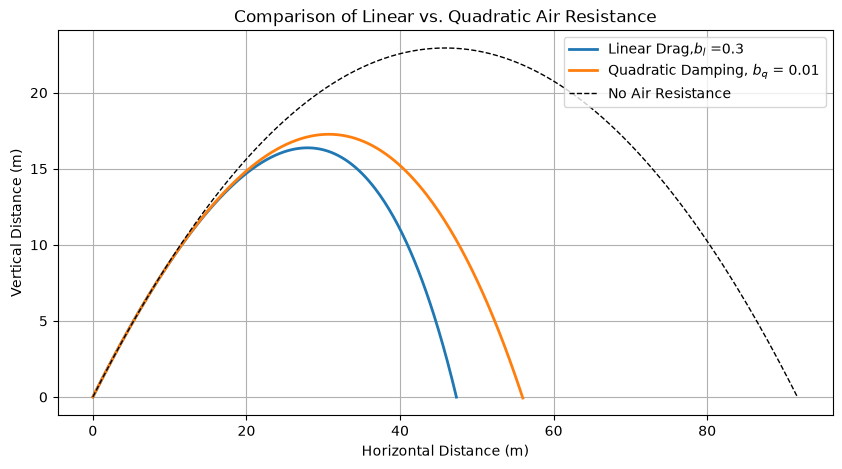

In [11]:

b_q = 0.01
b_l = b_q * u

plt.figure(figsize=(10, 5))
plt.plot(numerical_linear_drag_data(b_l,0.02)[1],numerical_linear_drag_data(b_l,0.02)[2],label="Linear Drag,$b_l$ =" + str(b_l), lw=2)
plt.plot(quadratic_drag_data(b_q,0.02)[1],quadratic_drag_data(b_q,0.02)[2], label ="Quadratic Damping, $b_q$ = " + str(b_q), lw=2)
plt.plot(x_i, y_i, label ="No Air Resistance", color='black', lw=1, ls='--')
plt.title('Comparison of Linear vs. Quadratic Air Resistance')
plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Vertical Distance (m)')
plt.grid()
plt.legend()
plt.show()


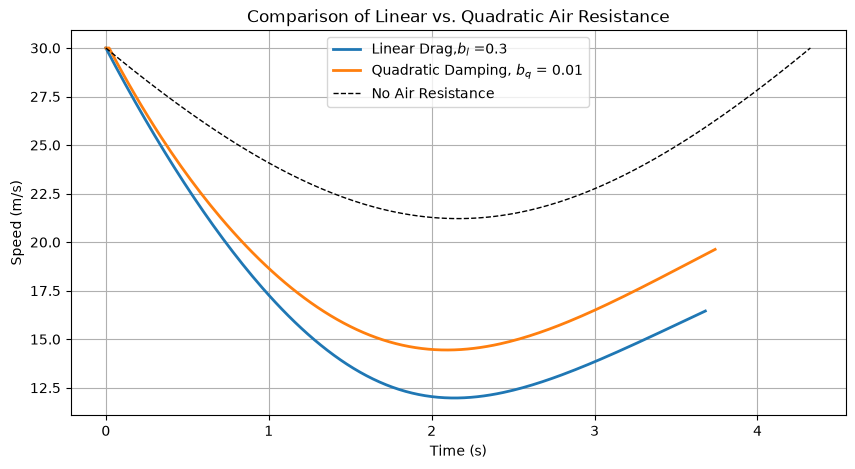

In [12]:

b_q = 0.01
b_l = b_q * u
## Speed-Time
plt.figure(figsize=(10, 5))
plt.plot(numerical_linear_drag_data(b_l,0.02)[0],numerical_linear_drag_data(b_l,0.02)[5],label="Linear Drag,$b_l$ =" + str(b_l), lw=2)
plt.plot(quadratic_drag_data(b_q,0.02)[0],quadratic_drag_data(b_q,0.02)[5], label ="Quadratic Damping, $b_q$ = " + str(b_q), lw=2)
plt.plot(t_i, np.sqrt((vx_i)**2 + (vy_i)**2), label ="No Air Resistance", color='black', lw=1, ls='--')
plt.title('Comparison of Linear vs. Quadratic Air Resistance')
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.grid()
plt.legend()
plt.show()


From these results, we can observe that flight paths for $P_l$, and the flight path for $P_q$ seen in the first graph is similar at early portions of the flight, but the differences start to increase as the projectile starts to slow down and reach its peak. In the speed-time graph the differences between the speeds is most prominent. This is significant because drag forces behave differently for the two different models. 

At $t=0$, both projectiles experience the same drag force. Values of $k_l$ and $k_q$ (and therefore $b_l$ and $b_q$) were calibrated specifically to create this effect as previously stated above. As the projectile flies, it slows down. 

In the model for linear drag, $F_d \propto v$, whereas $F_d \propto v^2$ in the case of quadratic damping. Because of this, the drag force in on $P_q$ decreases significantly as compared to the drag force on $P_l$.

Roughly speaking, if $v$ halves, $F_d$ halves in the linear case, but $F_d$ drops to a quarter of its original value in the quadratic case. The speed of the projecile slows down more in the linear model as compared to the quadratic model. This is also observed in the graph of the flight path, as $P_l$ drops below $P_q$.

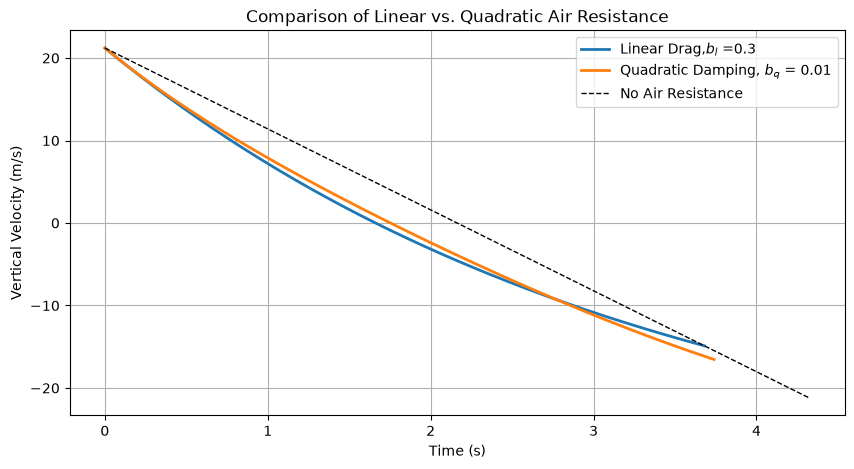

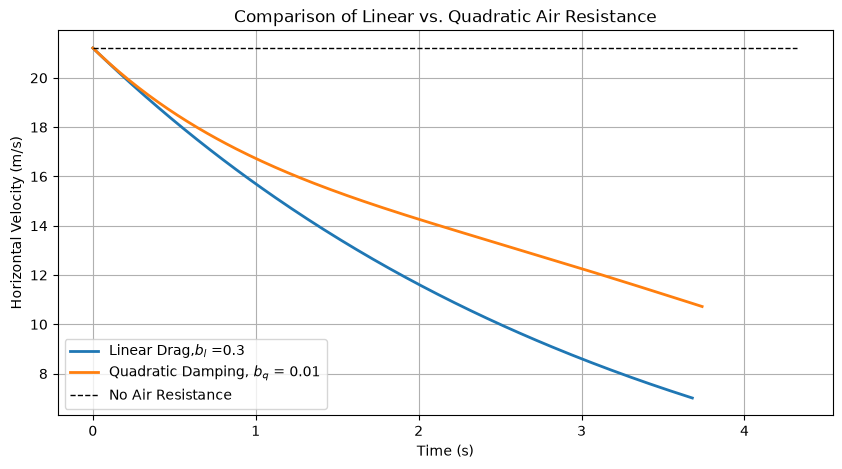

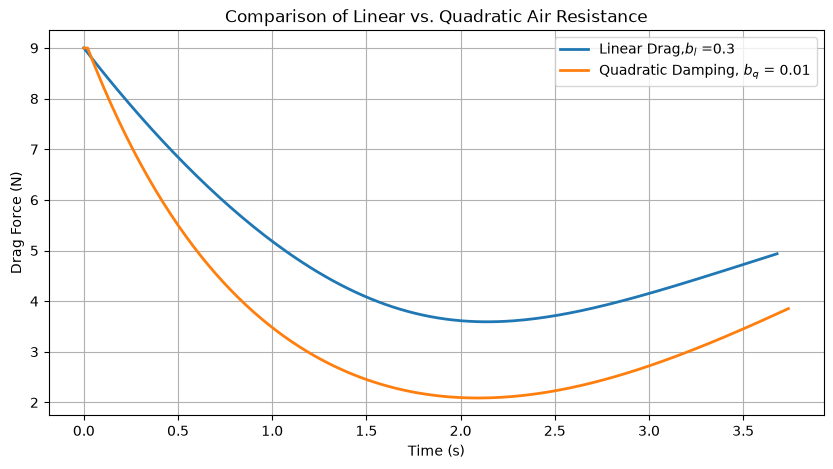

In [13]:
## Vertical velocity - Time
plt.figure(figsize=(10, 5))
plt.plot(numerical_linear_drag_data(b_l,0.02)[0],numerical_linear_drag_data(b_l,0.02)[4],label="Linear Drag,$b_l$ =" + str(b_l), lw=2)
plt.plot(quadratic_drag_data(b_q,0.02)[0],quadratic_drag_data(b_q,0.02)[4], label ="Quadratic Damping, $b_q$ = " + str(b_q), lw=2)
plt.plot(t_i, vy_i, label ="No Air Resistance", color='black', lw=1, ls='--')
plt.title('Comparison of Linear vs. Quadratic Air Resistance')
plt.xlabel('Time (s)')
plt.ylabel('Vertical Velocity (m/s)')
plt.grid()
plt.legend()
plt.show()
## Horizontal velocity - Time
plt.figure(figsize=(10, 5))
plt.plot(numerical_linear_drag_data(b_l,0.02)[0],numerical_linear_drag_data(b_l,0.02)[3],label="Linear Drag,$b_l$ =" + str(b_l), lw=2)
plt.plot(quadratic_drag_data(b_q,0.02)[0],quadratic_drag_data(b_q,0.02)[3], label ="Quadratic Damping, $b_q$ = " + str(b_q), lw=2)
plt.plot([0, t_i_0],[vx_i, vx_i],  label ="No Air Resistance", color='black', lw=1, ls='--')
plt.title('Comparison of Linear vs. Quadratic Air Resistance')
plt.xlabel('Time (s)')
plt.ylabel('Horizontal Velocity (m/s)')
plt.grid()
plt.legend()
plt.show()
## Drag Force - Time
F_l = [b_l * v for v in numerical_linear_drag_data(b_l,0.02)[5] ]
F_q = [b_q * v * np.abs(v) for v in quadratic_drag_data(b_q,0.02)[5] ]
plt.figure(figsize=(10, 5))
plt.plot(numerical_linear_drag_data(b_l,0.02)[0],F_l,label="Linear Drag,$b_l$ =" + str(b_l), lw=2)
plt.plot(quadratic_drag_data(b_q,0.02)[0],F_q, label ="Quadratic Damping, $b_q$ = " + str(b_q), lw=2)
plt.title('Comparison of Linear vs. Quadratic Air Resistance')
plt.xlabel('Time (s)')
plt.ylabel('Drag Force (N)')
plt.grid()
plt.legend()
plt.show()

## 6.2. Energy
The total energy of the projectile is given by 
$$
E = \frac{1}{2}mv^2 + mgy
$$

Given that the projectile experiences drag, there should be energy lost over time. $m = 0.1$ is chosen. This is the first time that a mass value of the projectile needed to be directly selected.

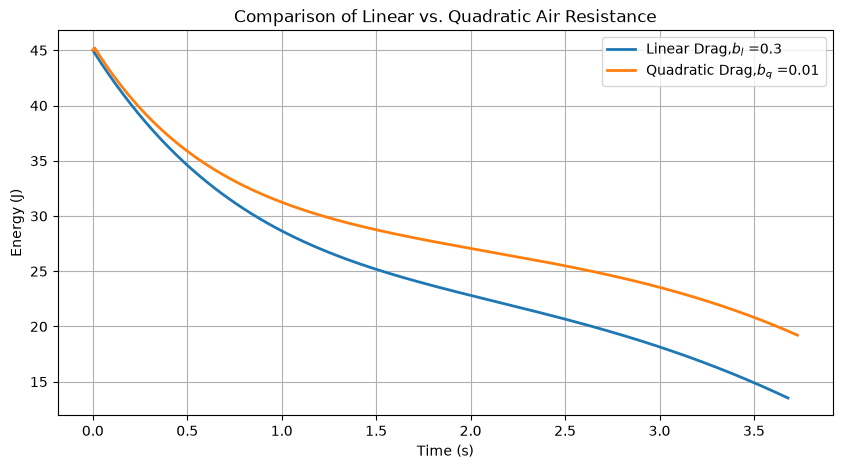

In [14]:
m=0.1
E_l = [
    1/2 * m * (v_l) **2 + m * g * y_l 
    for v_l, y_l in zip(numerical_linear_drag_data(b_l, 0.02)[5], numerical_linear_drag_data(b_l, 0.02)[2])]
E_q = [
    1/2 * m * (v_q) **2 + m * g * y_q 
    for v_q, y_q in zip(quadratic_drag_data(b_q,0.01)[5],quadratic_drag_data(b_q,0.01)[2])]



plt.figure(figsize=(10, 5))
plt.plot(numerical_linear_drag_data(b_l, 0.02)[0], E_l, label="Linear Drag,$b_l$ =" + str(b_l), lw=2)
plt.plot(quadratic_drag_data(b_q,0.01)[0], E_q, label="Quadratic Drag,$b_q$ =" + str(b_q), lw=2)
plt.title('Comparison of Linear vs. Quadratic Air Resistance')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.grid()
plt.legend()
plt.show()

Note: A minor numerical artifact is visible at the very beginning of the quadratic drag energy curve. This upward spike occurs because Euler's Method uses a finite time step to approximate a continuous process. At $t=0$, the drag force is very large ($F_d \propto v^2$), and the first discrete update slightly over-corrects the velocity before the position update compensates. This error disappears later and does not affect the overall energy trend.

## 6.3 Range, Time of Flight, Maximum Height
This subsection will discuss the differences in the values of Range, Time of Flight, and Maximum Height across the three models. The absence of drag in the ideal model means there is no energy loss, which is an obvious reason why it produces the greatest Range and Maximum Height. Furthermore, because it reaches the highest peak without drag slowing its ascent, it has the furthest distance to fall, resulting in the longest Time of Flight.

This subsection will analyze the differences in these three observations between the linear drag projectile ($P_l$) and the quadratic drag projectile ($P_q$), with the ideal case as an upper bound.


In [15]:
y_l_max = max(numerical_linear_drag_data(b_l, 0.01)[2])
y_q_max = max(quadratic_drag_data(b_q,0.01)[2])
print("The Maximum Height Achieved in the ideal case, under linear drag, and under quadratic drag is:")
print(round(y_i_max,1), "m (Ideal)")
print((round(y_l_max,1)), "m (Linear Drag)")
print((round(y_q_max,1)), "m (Quadratic Drag)")
print()

t_max_l = max(numerical_linear_drag_data(b_l, 0.01)[0])
t_max_q = max(quadratic_drag_data(b_q,0.01)[0])



print("The Time of Flight in the ideal case, under linear drag, and under quadratic drag is:")
print(round(t_i_0,2), "s (Ideal)")
print((round(t_max_l,2)), "s (Linear Drag)")
print((round(t_max_q,2)), "s (Quadratic Drag)")
print()

R_l = max(numerical_linear_drag_data(b_l, 0.01)[1])
R_q = max(quadratic_drag_data(b_q,0.01)[1])
print("The Range of the Projectile in the ideal case, under linear drag, and under quadratic drag is:")
print(round(R_ideal, 1), "m (Ideal)")
print(round(R_l, 1), "m (Linear Drag)")
print(round(R_q, 1), "m (Quadratic Drag)")
print()





The Maximum Height Achieved in the ideal case, under linear drag, and under quadratic drag is:
22.9 m (Ideal)
16.3 m (Linear Drag)
17.2 m (Quadratic Drag)

The Time of Flight in the ideal case, under linear drag, and under quadratic drag is:
4.32 s (Ideal)
3.68 s (Linear Drag)
3.73 s (Quadratic Drag)

The Range of the Projectile in the ideal case, under linear drag, and under quadratic drag is:
91.7 m (Ideal)
47.3 m (Linear Drag)
55.9 m (Quadratic Drag)



### Maximum Height
Maximum height is determined by the vertical displacement when vertical velocity reaches zero. 
$$
v_y = 0
$$

As seen from the vertical velocity - time graph, the projectile under linear drag reaches zero earlier than the projectile under quadratic drag. 
We can determine which projectile will have the greater maximum height (in this case given the chosen parameters) by considering the vertical acceleration.

The linear and quadratic drag force is given by
$$\vec{F_l}= -k_l \vec{v}$$
$$\vec{F_q}= -k_q v\vec{v}$$

The vertical component of component of drag force in the linear and quadratic cases are
$${F_l}_y= -k_l {v_y}$$
$${F_q}_y= -k_q v{v_y}$$
rearranging gives vertical acceleration
$$\frac{\mathrm{d}{v_y}_l}{\mathrm{d}t}= -g - \frac{k_l}{m}{v_y}_l$$
$$\frac{\mathrm{d}{v_y}_q}{\mathrm{d}t}= -g - \frac{k_q}{m}v{v_y}_q$$

In this specific case, $k_l$ and $k_q$ were calibrated such that at $t=0$, $\vec{F_l} = \vec{F_q}$. 

During the ascent, $v_y > 0$, and the speed of the projectile decreases to $v<u$ because of drag,:
$$
\begin{aligned}
k_q u u_y &= k_l u_y\\
\implies k_q u &= k_l \\
\implies k_q v &< k_q u \ (\text{because} \ v<u)\\
\implies k_q v &< k_l \ (\text{substituting} \  k_q u = k_l)\\
\implies k_q v v_y &< k_l v _y\ (\text{multiplying by} \ v_y>0)\\
\end{aligned}
$$
This gives

$$-g - \frac{k_q}{m}v{v_y}_q > -g - \frac{k_l}{m}{v_y}_l$$

Therefore, 
$$\frac{\mathrm{d}{v_y}_l}{\mathrm{d}t} < \frac{\mathrm{d}{v_y}_q}{\mathrm{d}t} < 0 $$
Both rate of changes are negative because the vertical velocity is always decreasing throughout the flight. Note that the vertical acceleration of $P_l$ is less than that of $P_q$. It is more negative, therefore downward acceleration is greater. 
This means that during the ascent, the vertical velocity of $P_l$ decreases faster as compared to $P_q$.
$P_l$ reaches its maximum height earlier than $P_q$ and achieves a lower maximum height. This is because $P_l$'s vertical velocity component decreases to $0$ faster than $P_q$ does. 


### Time of Flight
As the projectile starts descending, $v_y < 0$.  Therefore, following a similar logic to the process above:
$$
\begin{aligned}
k_q u u_y &= k_l u_y\\
\implies k_q u &= k_l \\
\implies k_q v &< k_q u \ (\text{because} \ v<u)\\
\implies k_q v &< k_l \ (\text{substituting} \  k_q u = k_l)\\
\implies k_q v v_y &> k_l v _y\ (\text{multiplying by} \ v_y<0)\\
\end{aligned}
$$

This gives

$$-g - \frac{k_q}{m}v{v_y}_q < -g - \frac{k_l}{m}{v_y}_l$$

Therefore, 
$$\frac{\mathrm{d}{v_y}_q}{\mathrm{d}t} < \frac{\mathrm{d}{v_y}_l}{\mathrm{d}t} < 0 $$

The vertical acceleration of $P_q$ is greater than that of $P_l$ during the descent. This means that even though $P_l$ begins its descent earlier than $P_q$, ${v_y}_q$ will eventually catch up to ${v_y}_l$. This can be observed in the graph of vertical velocity against time. The two graphs cross over at around $t=2.7s$. 

Consequently, as to whether or not $P_q$ will ever be lower than $P_l$  in vertical position is dependent upon the chosen parameters, and how much higher $P_q$ was than $P_l$ when they began their descent.  In this case,  because of the difference in maximum height, despite $P_q$ eventually overtaking $P_l$ in vertical speed, $P_l$ reached the ground earlier than $P_q$ because $P_l$'s maximum height was lower than that of $P_q$.

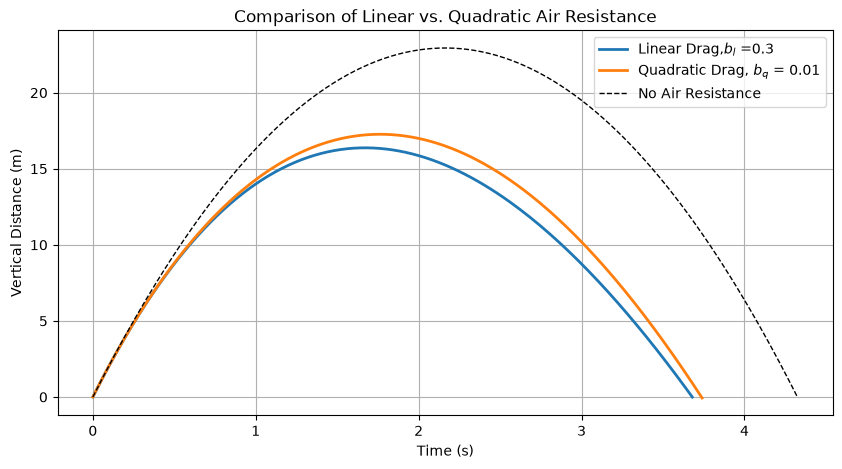

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(numerical_linear_drag_data(b_l,0.02)[0],numerical_linear_drag_data(b_l,0.02)[2],label="Linear Drag,$b_l$ =" + str(b_l), lw=2)
plt.plot(quadratic_drag_data(b_q,0.02)[0],quadratic_drag_data(b_q,0.02)[2], label ="Quadratic Drag, $b_q$ = " + str(b_q), lw=2)
plt.plot(t_i, y_i, label ="No Air Resistance", color='black', lw=1, ls='--')
plt.title('Comparison of Linear vs. Quadratic Air Resistance')
plt.xlabel('Time (s)')
plt.ylabel('Vertical Distance (m)')
plt.grid()
plt.legend()
plt.show()

### Range
The range of the projectile is given by $R = x(T) = \int_{0}^{T} v_x(t) \ \mathrm{d}t$ where $T$ is the Time of Flight. 
Range therefore depends on time of flight, $T$, and horizontal velocity, $v_x$.

For an ideal projectile, $v_x = u \cos{\theta} $ (Section 3.1)
$$R_{ideal} = x(T_{ideal}) = \int_{0}^{T_{ideal}}u \cos{\theta} \ \mathrm{d}t = u \cos{\theta} T_{ideal} $$
For $P_l$ and $P_q$, it is easy to see that drag will cause $v_x$ to decrease in both cases.  Moreover, their times of flight is also smaller as shown earlier. Thus, the projectile not only has less time to travel horizontally, but also covers less horizontal distance per unit time. Both effects therefore contribute to the reduction in range. 

The differences in Range between $P_l$ and $P_q$ can be explained with a similar logical process as above, but this time comparing $v_x$ rather than $v_y$.

The horizontal component of component of drag force in the linear and quadratic cases are
$${F_l}_x= -k_l {v_x}$$
$${F_q}_x= -k_q v{v_x}$$
rearranging gives horizontal acceleration
$$\frac{\mathrm{d}{v_x}_l}{\mathrm{d}t}= -g - \frac{k_l}{m}{v_x}_l$$
$$\frac{\mathrm{d}{v_x}_q}{\mathrm{d}t}= -g - \frac{k_q}{m}v{v_x}_q$$

In this specific case, $k_l$ and $k_q$ were calibrated such that at $t=0$, $\vec{F_l} = \vec{F_q}$. 
Throughout the flight, $v_x > 0$, and the speed of the projectile decreases to $v<u$ because of drag,:
$$
\begin{aligned}
k_q u u_x &= k_l u_x\\
\implies k_q u &= k_l \\
\implies k_q v &< k_q u \ (\text{because} \ v<u)\\
\implies k_q v &< k_l \ (\text{substituting} \  k_q u = k_l)\\
\implies k_q v v_x &< k_l v _x\ (\text{multiplying by} \ v_x>0)\\
\end{aligned}
$$
This gives

$$-g - \frac{k_q}{m}v{v_x}_q > -g - \frac{k_l}{m}{v_x}_l$$

Therefore, 
$$\frac{\mathrm{d}{v_x}_l}{\mathrm{d}t} < \frac{\mathrm{d}{v_x}_q}{\mathrm{d}t} < 0 $$

Horizontal acceleration of both $P_l$ and $P_q$ are negative,  but since horizontal acceleration for $P_l$ is more negative than $P_q$, 
$$
\begin{aligned}
\frac{\mathrm{d}{v_x}_l}{\mathrm{d}t} &< \frac{\mathrm{d}{v_x}_q}{\mathrm{d}t}\\

\implies \int_{0}^{t} \frac{\mathrm{d}{v_x}_l(\tau)}{\mathrm{d}\tau} \mathrm{d}\tau &< \int_{0}^{t} \frac{\mathrm{d}{v_x}_q(\tau)}{\mathrm{d}\tau} \ \mathrm{d}\tau\\
\implies {v_x}_l (t) - {v_x}_l(0) &< {v_x}_q (t) - {v_x}_q(0) \ (\text{Fundamental Theorem of Calculus})\\
\implies {v_x}_l(t) &< {v_x}_q (t) \    (\text{Eliminating}\ {v_x}_l(0) = {v_x}_q(0) = u_x)
\end{aligned}
$$
Therefore, 
$$
\begin{aligned}
{v_x}_l&< {v_x}_q\\
\implies \int_{0}^{T_l} {v_x}_l \ \mathrm{d}t &< \int_{0}^{T_q} {v_x}_q \ \mathrm{d}t\ (\text{Recall that} \ T_l < T_q)\\
\implies R_l &< R_q
\end{aligned}
$$

## 6.4 Terminal Velocity
It may be tempting to say that $P_q$ will accelerate downwards faster than $P_l$ indefinitely, provided that we allow the projectiles to keep falling even after it reaches $y=0$, however, $k_q v v_y > k_l v _y$ is dependent on $v<u$. 
$P_l$ has a theoretical terminal velocity of $\frac{g}{b_l} = \frac{mg}{k_l}$ (Section 4.3),  and $P_q$ $\sqrt{ \frac{g}{b_q}} = \sqrt{ \frac{mg}{k_q}}$(Section 5.2).  Both projectiles will accelerate towards their respective terminal velocities. 


In [17]:
v_t_l = g/b_l
v_t_q = np.sqrt(g / (b_q))

print("Terminal Velocity for P_l is ", round(v_t_l,1), " m/s")
print("Terminal Velocity for P_q is ", round(v_t_q,1), " m/s")
print("The value of u is ", u, " m/s")

Terminal Velocity for P_l is  32.7  m/s
Terminal Velocity for P_q is  31.3  m/s
The value of u is  30  m/s


#### $v_t > u$
The value of terminal velocity for $P_l$ is larger than that of $P_q$. Both are larger than the launch speed $u$.

This is a case where terminal velocity $v_t$ could be is than $u$.

As shown above, 
$$\frac{\mathrm{d}{v_y}_q}{\mathrm{d}t} < \frac{\mathrm{d}{v_y}_l}{\mathrm{d}t} < 0 \tag{1}$$
if $v<u$

This shows that $P_q$ accelerates downwards faster than $P_l$ does. $P_l$ begins its downward descent earlier than $P_q$ does, but $P_q$ eventually overtakes $P_l$ in vertical speed as seen in the graph of vertical velocity against time. After some point in time, $P_q$ is moving faster downwards than $P_l$ is, and is also accelerating downwards at a greater rate. It seems impossible that $P_l$ later achieves a greater terminal velocity because it can never catch up to $P_q$.

Recall that the assumption made to reach the conclusion in equation (1) is that $v < u$.

This is not going to be true indefinitely. As the projectiles fall, they accelerate. Eventually, their total speed $v$ exceeds the launch speed $u$. At this point, the assumption 
$v<u$ is violated. We know this because the terminal velocity is greater than u $v_t > u$,so the projectile will eventually accelerate past $u$.

If $v > u$, 
$$
\begin{aligned}
k_q u u_y &= k_l u_y\\
\implies k_q u &= k_l \\
\implies k_q v &> k_q u \ (\text{because} \ v> u)\\
\implies k_q v &> k_l \ (\text{substituting} \  k_q u = k_l)\\
\implies k_q v v_y &< k_l v _y\ (\text{multiplying by} \ v_y<0)\\
\end{aligned}
$$
Which leads to 
$$\frac{\mathrm{d}{v_y}_l}{\mathrm{d}t} < \frac{\mathrm{d}{v_y}_q}{\mathrm{d}t} < 0$$

This shows that near terminal velocity, $P_l$ accelerates faster than $P_q$. $P_l$ continues to accelerate until it reaches its terminal velocity ${v_t}_l$, while $P_q$ stops accelerating at its lower terminal velocity ${v_t}_q$

#### $v_t < u$
It is possible that terminal velocity is less than $u$,In that case, the condition $v>u$ is never met.After $P_q$'s downward speed becomes greater than that of  $P_l$, $P_q$ will always be moving faster downwards than $P_l$ for the rest of their indefinite journey. The inequality
$$\frac{\mathrm{d}{v_y}_q}{\mathrm{d}t} < \frac{\mathrm{d}{v_y}_l}{\mathrm{d}t} < 0$$
always holds true. It now seems impossible that $P_l$ can reach a greater terminal velocity than $P_q$.

$$\begin{aligned}
{v_t}_l &= \frac{mg}{k_l}\\
{v_t}_q &= \sqrt{ \frac{mg}{k_q}}
\end{aligned}$$

However,because $k_q u = k_l$ was the calibration made,
$${v_t}_q = \sqrt{ \frac{mg}{\frac{k_l}{u}}} = \sqrt{\frac{mgu}{k_l}}= \sqrt{u\frac{mg}{k_l}}=\sqrt{u{v_t}_l}$$

If ${v_t}_l < u$, then
$${v_t}_l < u \implies u{v_t}_l < u^2 \implies \sqrt{u{v_t}_l} < u \implies {v_t}_q < u$$
also,
$${v_t}_l < u \implies {{v_t}_l}^2 < u{{v_t}_l} \implies {v_t}_l < \sqrt{u{{v_t}_l}} = {v_t}_q
\implies {v_t}_l < {v_t}_q$$

$$\boxed{{v_t}_l < u \implies {v_t}_l < {v_t}_q < u}$$
This means that given the initial condition that $\vec{{F_d}_l} = \vec{{F_d}_q}$, $P_q$ will have a greater terminal velocity than $P_l$, if both terminal velocities are less than $u$.

By considering ${v_t}_l > u$ and using a similar logical process, 
$${v_t}_l > u \implies u{v_t}_l > u^2 \implies \sqrt{u{v_t}_l} > u \implies {v_t}_q > u$$
and
$${v_t}_l > u \implies {{v_t}_l}^2 > u{{v_t}_l} \implies {v_t}_l > \sqrt{u{{v_t}_l}} = {v_t}_q
\implies {v_t}_l > {v_t}_q$$

$$\boxed{{v_t}_l > u \implies u < {v_t}_q < {v_t}_l}$$

This means that given the initial condition that $\vec{{F_d}_l} = \vec{{F_d}_q}$, $P_l$ will have a greater terminal velocity than $P_q$, if both terminal velocities are greater than $u$.

## 6.5. Optimal Launch Angle
The range of the projectile, $R$ is dependent only on variables $u$ and $\theta$.
$$R = \frac{u^2 \sin(2\theta)}{g}$$
If $\theta$ is fixed and $R$ varies only in terms of $u$, $R \propto u^2$

If $u$ is fixed and $R$ varies only in terms of $\theta$, it is possible to find a value of $\theta$ such that $R$ is maximised.
$$\begin{aligned}
\frac{\mathrm{d}R}{\mathrm{d}\theta} = \frac{2u^2 \cos{2\theta}}{g}&= 0\\
\implies \cos{2\theta} &=0\\
\implies \theta &=\frac{\pi}{4}
\end{aligned}$$



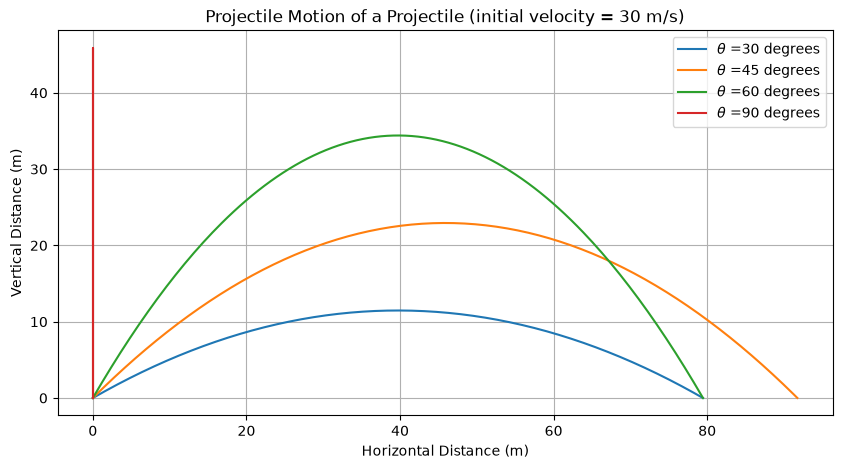

In [18]:
plt.figure(figsize=(10, 5))
plt.plot((ideal_model_data(30)[1]), ideal_model_data(30)[2],label ="$\\theta$ =" +str(30) + " degrees")
plt.plot(ideal_model_data(45)[1], ideal_model_data(45)[2], label ="$\\theta$ ="+ str(45)+ " degrees")
plt.plot(ideal_model_data(60)[1], ideal_model_data(60)[2], label ="$\\theta$ =" +str(60)+" degrees")
plt.plot(ideal_model_data(90)[1], ideal_model_data(90)[2], label ="$\\theta$ ="+str(90)+ " degrees")
plt.title('Projectile Motion of a Projectile (initial velocity = 30 m/s)')
plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Vertical Distance (m)')
plt.grid() 
plt.legend()
plt.show()

For $P_l$, it is possible to find an expression for Time of Flight, $T_l$ as $\theta$ varies, but it is impossible to express $T$ using elementary functions. Thus, for $P_l$, it is impossible to find a elementary expression for the range, $R_l$.

For $P_q$, it is impossible to find an elementary expression for $T_q$ and $R_q$. Thus, we will plot a graph of range against launch angle. We will calculate the ranges of $P_q$ and $P_l$ varying only with launch angle $\theta$. This, again is done using Euler's Method, similar to the numerical methods shown above in Section 4.4, and Section 5.1, but instead plotting Range against Launch Angle rather than the vertical displacement against horizontal displacement.



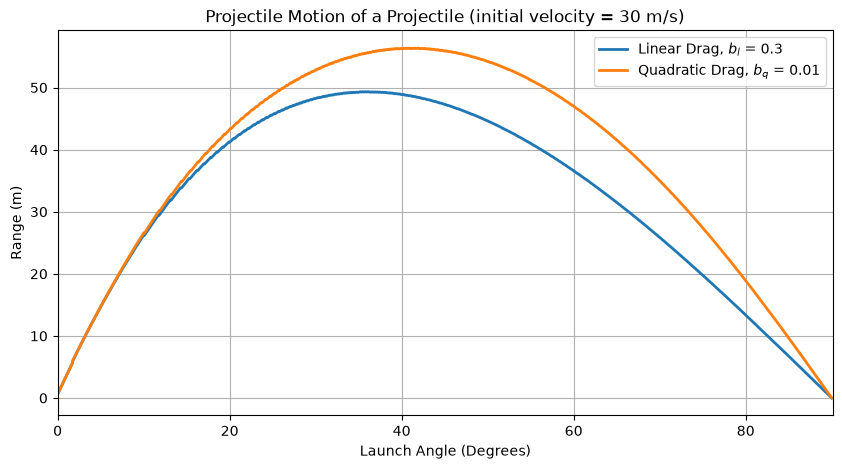

In [19]:
def quadratic_drag_range(u, theta, b,dt):
    
    theta0 = np.radians(theta)  # Launch angle in radians
    v0 = u  # Initial velocity (m/s)
    g = 9.81  # Acceleration due to gravity (m/s^2)

    x = 0
    y = 0
    vx = v0 * np.cos(theta0)
    vy = v0 * np.sin(theta0)

    while y >= 0:

        # Euler updates
        x = x + vx * dt
        y = y + vy * dt
        V=np.sqrt((vx)**2+(vy)**2)
        vx = vx + (-b * V * vx) * dt
        vy = vy + (-g -b * V * vy ) * dt

     
    return(x)

def linear_drag_range(u, theta, b,dt):
    theta0 = np.radians(theta)  # Launch angle in radians
    v0 = u  # Initial velocity (m/s)
    g = 9.81  # Acceleration due to gravity (m/s^2)
    x = 0
    y = 0
    vx = v0 * np.cos(theta0)
    vy = v0 * np.sin(theta0)

    while y >= 0:

        # Euler updates
        x = x + vx * dt
        y = y + vy * dt
        vx = vx + (-b * vx) * dt
        vy = vy + (-b * vy - g) * dt
        v=np.sqrt((vx)**2 + (vy)**2)

    return (x)

angles = np.linspace(0.1, 90.0, 900)

R_q = []
R_l = []
for angle in angles:
    R = quadratic_drag_range(30, angle, b_q, 0.01)
    R_q.append(R)

for angle in angles:
    R = linear_drag_range(30, angle, b_l, 0.01)
    R_l.append(R)

plt.figure(figsize=(10, 5))
plt.plot(angles, R_l, label ="Linear Drag, $b_l$ = " + str(b_l), lw=2)
plt.plot(angles, R_q, label ="Quadratic Drag, $b_q$ = " + str(b_q), lw=2)
plt.title('Projectile Motion of a Projectile (initial velocity = 30 m/s)')
plt.xlabel('Launch Angle (Degrees)')
plt.xlim(0,max(angles)+0.1)
plt.ylabel('Range (m)')
plt.grid() 
plt.legend()
plt.show()

In [20]:
max_index_l = np.argmax(R_l)
optimal_angle_l = angles[max_index_l]
maximum_R_l = R_l[max_index_l]
print("Optimal angle for P_l:", round(optimal_angle_l,1),"degrees")
print("Maximum range of P_l:", round(maximum_R_l,1),"m")

max_index_q = np.argmax(R_q)
optimal_angle_q = angles[max_index_q]
maximum_R_q = R_q[max_index_q]
print("Optimal angle for P_q is:", round(optimal_angle_q,1),"degrees")
print("Maximum range of P_q is:", round(maximum_R_q,1),"m")


Optimal angle for P_l: 36.1 degrees
Maximum range of P_l: 49.3 m
Optimal angle for P_q is: 40.8 degrees
Maximum range of P_q is: 56.4 m


The range was calculated for launch angles between $0.1^\circ$ degrees and $89.9^\circ$ in $0.1^\circ$ increments. The angle producing the greatest range was identified as the optimal launch angle.

# 7. Applicability of the drag models to the real world
In this section we will discuss the use cases of a linear drag model and a quadratic drag model. 

## 7.1. Reynolds number
Drag force or air resistance has a magnitude that depends on speed. For linear drag, $|{F_d}_l| \propto v$, whereas for quadratic drag, $|{F_d}_q|\propto v^2$. However, air resistance is not fixed to either one of these two models. It varies based on the air flow around the projectile. The two behaviours of air resistance depends on a quantity called Reynolds Number.

For an object moving through a fluid, 
$$Re = \frac{\rho v L}{\mu}$$
where $\rho$ is the density of the fluid, $v$ is the speed of the object relative to the fluid, $L$ is the length of the object, $\mu$ is the dynamic viscosity of the fluid (the resistive force between fluid as volumes of fluid flow past each other). 
In general, Reynolds Number measures the ratio between inertial and viscous effects.

Since, $v=v(t)$, $$Re(t) = \frac{\rho v(t) L}{\mu}$$

We will choose values for $\rho$, $L$ and $\mu$

The density of air at sea level and $15$ °C under standard conditions is approximately $1.225$ kg/m^3. $\rho = 1.225$

We will choose the diameter of the projecile to be $L = 0.1$ m

At standard conditions $15$ °C, the dynamic viscosity of air is 1.81 × 10^-5 Pa s. $\mu = 1.81$


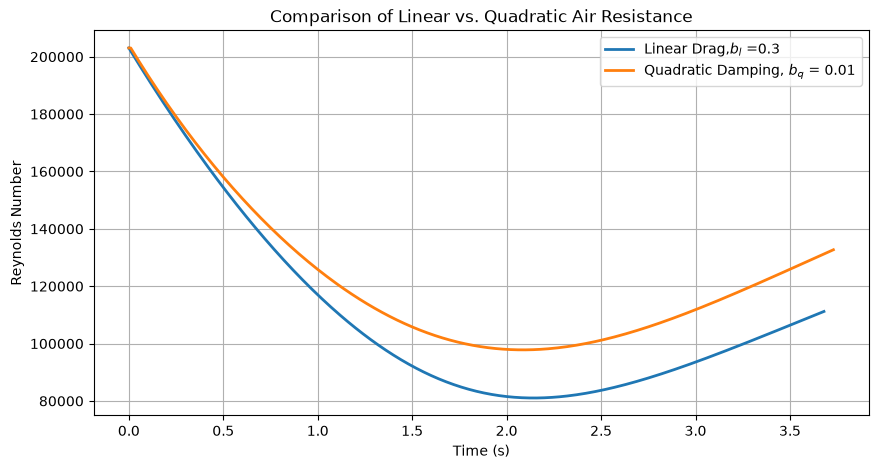

In [21]:
rho = 1.225
L = 0.1
mu = 1.81 * 10**(-5)

def Re(vs):
    return (rho * L / mu) * np.array(vs)

Re_l = Re(numerical_linear_drag_data(b_l,0.01)[5])
Re_q = Re(quadratic_drag_data(b_q,0.01)[5])

plt.figure(figsize=(10, 5))
plt.plot(numerical_linear_drag_data(b_l,0.01)[0],Re_l,label="Linear Drag,$b_l$ =" + str(b_l), lw=2)
plt.plot(quadratic_drag_data(b_q,0.01)[0],Re_q, label ="Quadratic Damping, $b_q$ = " + str(b_q), lw=2)
plt.title('Comparison of Linear vs. Quadratic Air Resistance')
plt.xlabel('Time (s)')
plt.ylabel('Reynolds Number')
plt.grid()
plt.legend()
plt.show()

The Reynolds number was calculated throughout the flight for both the linear and quadratic drag models investigated in Section 6. In both simulations, the Reynolds number remained above approximately $80000$. Reynolds Number measures the ratio of inertial effects and viscous effects in the flow. Low values of $Re$ indicates viscous effects are stronger, whereas high $Re$ indicates inertial effects are stronger. 

## 7.2. Linear Drag vs Quadratic Drag
For linear drag,
$$|F_d| = 6 \pi \mu R v$$
where
$\mu$ is the dynamic viscosity of the fluid, $R$ is the radius of the sphere, $v$ is velocity

For quadratic drag,
$$|{F_d}| = \frac{1}{2} c_d \rho A v^2$$
where $F_d$ is the drag force, $c_d$ is the drag coefficient, $\rho$ is the air density, $A$ is the cross-sectional area of the projectile, $v$ is the velocity of the projectile. 

Typically, Linear Drag, $F_d \propto v$ is characterised by low $Re$, ($Re \leq 1$), whereas Quadratic Drag is commonly used for objects moving through air at high $Re$ values.  The Reynolds numbers obtained in these simulations are much higher than those associated with the low Reynolds Numbers in which linear drag is typically used. Though the Reynolds number decreases during the flight as the projectile loses speed, it remains at relatively high values throughout the simulated trajectory. This suggests that the quadratic drag model is more appropriate model for simplicity for an ordinary projectile moving through air under the conditions considered here.

However, the quadratic drag model still makes idealised assumptions, an example of which being that $F_d=kv^2$ where $k$ is constant. In reality, Though $A$ is constant and $\rho$ is approximately constant, $C_D$ varies with Reynolds Number and other conditions. Therefore, the quadratic drag model is still a simplification of the complicated real-world aerodynamics.

# 8. Hitting a Target
In the Section 6.5, it was investigated how the launch angle affects the range of a projectile and how to determine the angle that maximises it. However, in this section the objective is not to maximise range, but rather to reach a specific target position. In this section, we will investigate how the launch conditions can be chosen so that a projectile reaches a given target coordinate $(x_T, y_T)$ and how air resistance affects the required launch conditions.

## 8.1 Ideal Projectile

## 8.1.1. Analytical Solution
For an ideal projectile with launch speed $u$,
$$\begin{aligned}
x(t) &= u \cos{\theta} t\\
y(t) &= u \sin{\theta} t - \frac{1}{2} g t^2
\end{aligned}
$$
Suppose that at time $t_0$, the projectile hits the target at $(x_T, y_T)$.     
$$x_T = u \cos{\theta} t_0 \tag{1}$$
$$y_T = u \sin{\theta} t_0- \frac{1}{2} g {t_0}^2 \tag{2}$$

By rearranging for $t_0$ from $(1)$,
$$t_0 = \frac{x_T}{u \cos{\theta}}$$

Substituting into $(2)$, 
$$y_T = x_T \tan{\theta} - \frac{g {x_T}^2}{2 u^2 \cos^2{\theta}}$$

By solving for $\theta$, 
$$\begin{aligned}
y_T &= x_T \tan{\theta} - \frac{g {x_T}^2}{2 u^2}\sec^2{\theta}\\
y_T &= x_T \tan{\theta} - \frac{g {x_T}^2}{2 u^2}\tan^2{\theta} - \frac{g {x_T}^2}{2 u^2} \ (\text{subtituting} \sec^2{\theta} = 1 + \tan^2{\theta})\\
\end{aligned}
$$
which leads to a quadratic equation in $\tan(\theta)$
$$\frac{g {x_T}^2}{2 u^2}\tan^2{\theta} - x_T \tan{\theta} + y_T + \frac{g {x_T}^2}{2 u^2}$$

$$\begin{aligned}
\implies \tan{\theta} &= \frac{u^2 \pm \sqrt{u^4 -g(g {x_T}^2 +2y_T u^2)}}{g x_T}\\
\implies \theta &= \arctan(\frac{u^2 \pm \sqrt{u^4 -g(g {x_T}^2 +2y_T u^2)}}{g x_T})
\end{aligned}$$

Let $D = u^4 -g(g {x_T}^2 +2y_T u^2 )$.

If  $D>0$, this indicates that there are two possible launch angles for a projectile launched with speed $u$ to reach $(x_T, y_T)$.

If  $D=0$, there is only one launch angle that can hit the target $(x_T, y_T)$.

If $D< 0$, the launch speed $u$ is insufficient to hit the target $(x_T, y_T)$.

From the expression $u^4 -g(g {x_T}^2 +2y_T u^2 )$ we can also find the minimum speed needed to reach the chosen target coordinate. 

By setting $u^4 -g(g {x_T}^2 +2y_T u^2 ) \geq 0$ and rearranging for $u$,
$$u^4 -2gy_Tu^2 -g^2 {x_T}^2 \geq 0$$
To find the minimum value of $u$, we set $$u^4 -2gy_Tu^2 -g^2 {x_T}^2 = 0$$
This is a quadratic equation in $u^2$. 
$$u^2 = g( y_T \pm \sqrt{{y_T}^2+{x_T}^2})$$

The $-$ case of the square root is ignored because $u >0$
$$ y_T - \sqrt{{y_T}^2+{x_T}^2} > 0 \implies {x_T}^2 < 0$$

Therefore
$$\begin{aligned}
u^2 &= g( y_T + \sqrt{{y_T}^2+{x_T}^2})\\
\implies u &=\sqrt{ g( y_T + \sqrt{{y_T}^2+{x_T}^2}) }
\end{aligned}$$ 
is the minimum launch speed to reach target $(x_T,y_T)$

### 8.1.2. Choosing a target
An aribitrary coordinate is chosen. Target coordinate is $(50, 10)$ m.

In [22]:
def D(x,y):
    return u ** 4 -( g * ((g * x ** 2) + (2 * y * u**2) ))

xT=50
yT=10
print("D is", D(xT,yT))

D is 392829.75


Since $D$ is larger than zero for the target coordinates chosen, there will be two different launch angles that will reach the target, given the launch speed is $u=30$ m/s.

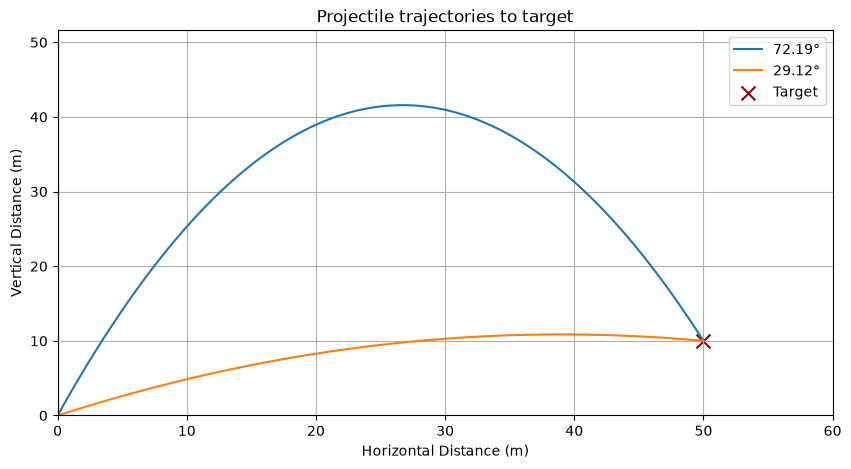

Launch angles that let the projectile hit the target are approximately: 72.19 degrees, and 29.12 degrees


In [23]:
def ideal_target(theta, u):

    theta_rad = np.radians(theta)

    t_T = xT / (u * np.cos(theta_rad))

    t = np.linspace(0, t_T, num=200)

    x = u * np.cos(theta_rad) * t
    y = u * np.sin(theta_rad) * t - 0.5 * g * t**2

    vx = u * np.cos(theta_rad)
    vy = u * np.sin(theta_rad) - g * t

    return t, x, y, vx, vy


theta_T1 = np.degrees(np.arctan(
    (u**2 + np.sqrt(D(xT, yT))) / (g * xT)
))

theta_T2 = np.degrees(np.arctan(
    (u**2 - np.sqrt(D(xT, yT))) / (g * xT)
))


t1, x1, y1, vx1, vy1 = ideal_target(theta_T1, u)
t2, x2, y2, vx2, vy2 = ideal_target(theta_T2, u)


plt.figure(figsize=(10, 5))
plt.plot(x1, y1, label=f'{theta_T1:.2f}°')
plt.plot(x2, y2, label=f'{theta_T2:.2f}°')
plt.scatter(xT, yT, marker='x', s=100, label='Target',color="darkred")
plt.title('Projectile trajectories to target')
plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Vertical Distance (m)')
plt.xlim(0, xT + 10)
plt.ylim(0, max(max(y1), max(y2)) + 10)
plt.grid()
plt.legend()
plt.show()

print("Launch angles that let the projectile hit the target are approximately:", round(theta_T1,2),"degrees, and", round(theta_T2,2), "degrees")

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.set(xlabel='Horizontal Distance (m)', ylabel='Vertical Distance (m)')
ax.set_xlim(0, xT + 10)
ax.set_ylim(0, max(max(y1), max(y2)) + 10)
ax.set_aspect('equal')
ax.grid()
ax.set_title("Projectile Motion")

trajectory1, = ax.plot([], [], '--', color = "orange")
trajectory2, = ax.plot([], [], '--',color="blue")

projectile1, = ax.plot([], [], 'o', color="orange")
projectile2, = ax.plot([], [], 'o',color="blue")

target = ax.scatter(xT, yT, marker='x', s=100, label='Target',color="darkred")

t_animation = np.linspace(0,max(t1[-1], t2[-1]),300)

frames = len(t_animation)

def update(frame):

    current_time = t_animation[frame]

    # Position of projectile 1 at current physical time
    x_1 = np.interp(current_time, t1, x1)
    y_1 = np.interp(current_time, t1, y1)

    # Position of projectile 2 at current physical time
    x_2 = np.interp(current_time, t2, x2)
    y_2 = np.interp(current_time, t2, y2)

    # Trajectory up to current time
    mask1 = t1 <= current_time
    mask2 = t2 <= current_time

    trajectory1.set_data(x1[mask1], y1[mask1])
    trajectory2.set_data(x2[mask2], y2[mask2])

    # Current projectile positions
    projectile1.set_data([x_1], [y_1])
    projectile2.set_data([x_2], [y_2])

    return trajectory1, trajectory2, projectile1, projectile2
    trajectory1.set_data(x1[:frame+1], y1[:frame+1])
    trajectory2.set_data(x2[:frame+1], y2[:frame+1])

    projectile1.set_data([x1[frame]], [y1[frame]])
    projectile2.set_data([x2[frame]], [y2[frame]])

    return trajectory1, trajectory2, projectile1, projectile2
ani = FuncAnimation(
    fig,
    update,
    frames=len(t_animation),
    interval=20,
    blit=True
)

plt.close(fig)

# Save GIF
ani.save("ideal_target_animation.gif", writer="pillow", fps=30)

The two launch angles allow the projectile to reach the same target position, but they generally require different flight times.

## 8.2. Projectile with Air Resistance 
As mentioned in Section 7.2, quadratic drag is more appropriate to be used as a drag model because the motion of a projectile through air typically has a Reynolds Number much higher than that of those associated with linear drag. 
$$|{F_d}| = \frac{1}{2} c_d \rho A v^2$$
The projectile will be modelled after a baseball. 

$m=0.15$ kg

$D = 0.075$ m $\implies A = \pi (\frac{D}{2})^2$

$\rho = 1.225$ kg/m^3, as mentioned earlier, this is the density of air at sea level and $15$ °C under standard conditions.

From other studies, the drag coefficient of a sphere with Reynolds Number approximately 10^4 was measured to be about 0.47. In this model, the drag coefficient will be modelled as constant. 

$c_D = 0.47$

$k = \frac{1}{2} c_d \rho A$

$b = \frac{ c_d \rho A}{2m}$


In [25]:
m = 0.15
Diameter = 0.075
A = np.pi * (Diameter/2)**2
rho = 1.225
c_D = 0.47
k = 0.5 * c_D * rho * A
b = k/m

print("k is ", k)
print("b is ", b)

k is  0.0012717927916202274
b is  0.008478618610801516


Coincidently, this value of $b$ is close to the test value $b_q = 0.01$ earlier.

Again, there are no elementary solutions for the equations of motion of a projectile experiencing quadratic drag. This simulation will be performed numerically using an iterative process.

Methodology:
1. Two trial angles will be chosen, $\theta_1$ and $\theta_2$
2. The flight paths of the projectile with these two trial angles will be numerically calculated
3. The simulation will be stopped when $x \geq x_T$
4. The $y$ value will be calculated for these particular trajectories when $x=x_T$
5. An error function will be defined as $E(\theta) = y_{projectile} - y_T$
6. The goal will be to find a $\theta$ such that $E(\theta) = 0$
7. The Bisection Method is used to find a root of the equation $E(\theta) = 0$

The Bisection Method uses two trial values for the roots, $\theta_1$ and $\theta_2$, where $E(\theta_1)$ and $E(\theta_2)$ have opposite signs. By the Intermediate Value Theorem, since $E(\theta_r) = 0$ is between $E(\theta_1)$ and $E(\theta_2)$, $\theta_r \ \epsilon [\theta_1, \theta_2]$. 

Then, choose $\theta_3 = \frac{\theta_1 + \theta_2}{2}$

We will define a sign function such that $sgn(a) = 1$ if $a >0$, $sgn(a) = -1$ if $a<0$, or $sgn(a) = 0$ if $a=0$.

If $sgn(E(\theta_3))  = sgn(E(\theta_1)) = -1 $, then $\theta_r \epsilon [\theta_3, \theta_2]$.
We update $\theta_1 = \theta_3$.

If $sgn(E(\theta_3) ) = sgn(E(\theta_2))$, then $\theta_r \epsilon [\theta_1, \theta_3]$.
We update $\theta_2 = \theta_3$.

If $sgn(E(\theta_3))=0$, then $\theta_3 = \theta_r$ but this should be almost impossible.

This process is then repeated until a sufficient level of precision for $\theta_r$  is reached


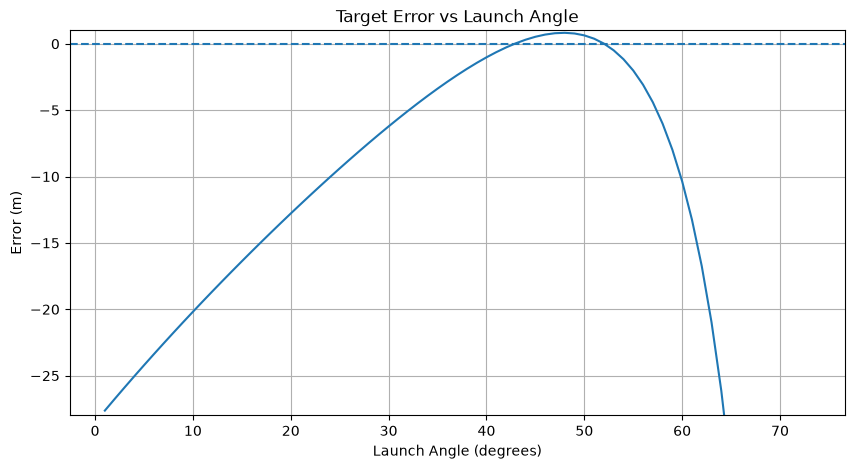

In [26]:
xT=50
yT=10

def error(theta, b, u, dt):
    theta0 = np.radians(theta)
    g = 9.81

    x = 0.0
    y = 0.0

    vx = u * np.cos(theta0)
    vy = u * np.sin(theta0)

    max_steps = 10000

    for _ in range(max_steps):
        x_old = x
        y_old = y

        V = np.sqrt(vx**2 + vy**2)

        x = x + vx * dt
        y = y + vy * dt

        vx = vx - b * V * vx * dt
        vy = vy + (-g - b * V * vy) * dt

        if x >= xT:

            # Linear interpolation
            y_T_est = y_old + (y - y_old) * (xT - x_old) / (x - x_old)

            return y_T_est - yT

    return np.nan
thetas = np.linspace(1, 89, 89)

errors = []

for theta in thetas:
    errors.append(error(theta, b, 30,0.01))

plt.figure(figsize=(10, 5))
plt.plot(thetas, errors)

plt.axhline(0, linestyle='--')

plt.xlabel('Launch Angle (degrees)')
plt.ylabel('Error (m)')
plt.title('Target Error vs Launch Angle')
plt.ylim(math.floor(errors[0]),math.ceil(max(errors)))
plt.grid()
plt.show()

This means there are two launch angles that can reach the target coordinate.

In [27]:
def sgn(a):
    if a < 0:
        return -1
    if a > 0:
        return 1
    else:
        return 0

def E(theta):
    return error(theta, b, u, 0.01)

def bisection(theta_1, theta_2, precision):

    E1 = E(theta_1)
    E2 = E(theta_2)
    while True:

        theta_3 = (theta_1 + theta_2) / 2
        E3 = E(theta_3)

        if np.abs(E3) < precision:
            return theta_3

        if sgn(E3) == sgn(E1):
            theta_1 = theta_3
            E1 = E3
        if sgn(E3) == sgn(E2):
            theta_2 = theta_3
        if sgn(E3) == 0:
            return theta_3

Root_1 = bisection(40, 50, 10**(-6))

print("Root 1 is ", Root_1)
print("The error is", E(Root_1))

Root_2 = bisection(50,60,10**(-6))
print("Root 2 is ", Root_2)
print("The error is", E(Root_2))


Root 1 is  42.87691593170166
The error is -3.782402142604724e-07
Root 2 is  52.0331072807312
The error is 4.530882335984643e-08


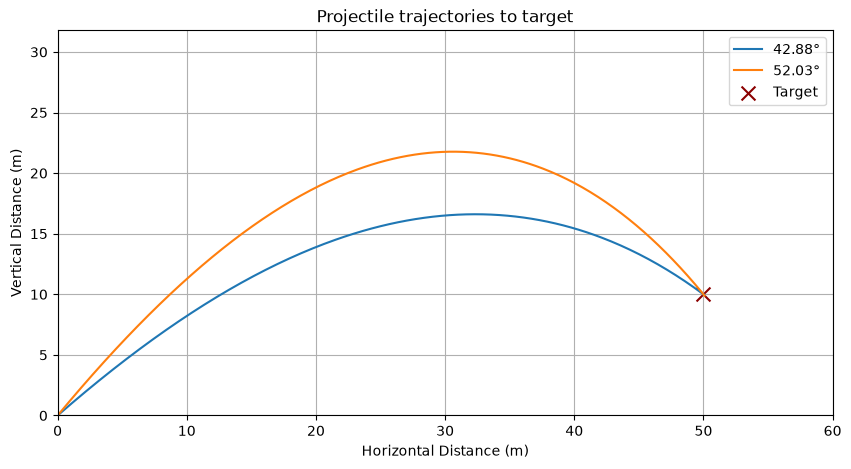

In [28]:
def real_target(theta,b,dt):
    theta = np.radians(theta)
    v0 = 30  # Initial velocity (m/s)
    g = 9.81  # Acceleration due to gravity (m/s^2)

    x = 0
    y = 0
    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)

    xt = [x]
    yt = [y]
    vxt = [vx]
    vyt = [vy]
    t = [0]
    Vt =[v0]
    while x <= xT:

        x_old = x
        y_old = y

        V = np.sqrt(vx**2 + vy**2)

        x = x + vx * dt
        y = y + vy * dt

        vx = vx + (-b * V * vx) * dt
        vy = vy + (-g - b * V * vy) * dt

        xt.append(x)
        yt.append(y)
        vxt.append(vx)
        vyt.append(vy)
        t.append(t[-1] + dt)
        Vt.append(V)
    
    return t,xt,yt,vxt,vyt,Vt

t1, x1, y1, vx1, vy1, v1 = real_target(Root_1, b,0.01)
t2, x2, y2, vx2, vy2, v2 = real_target(Root_2, b,0.01)

t1 = np.array(t1)
x1 = np.array(x1)
y1 = np.array(y1)

t2 = np.array(t2)
x2 = np.array(x2)
y2 = np.array(y2)

plt.figure(figsize=(10, 5))
plt.plot(x1, y1, label=f'{Root_1:.2f}°')
plt.plot(x2, y2, label=f'{Root_2:.2f}°')
plt.scatter(xT, yT, marker='x', s=100, label='Target',color="darkred")
plt.title('Projectile trajectories to target')
plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Vertical Distance (m)')
plt.xlim(0, xT + 10)
plt.ylim(0, max(max(y1), max(y2)) + 10)
plt.grid()
plt.legend()
plt.show()



In [29]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.set(
    xlabel='Horizontal Distance (m)',
    ylabel='Vertical Distance (m)'
)

ax.set_xlim(0, xT + 10)
ax.set_ylim(0, max(max(y1), max(y2)) + 10)
ax.set_aspect('equal')
ax.grid()
ax.set_title("Projectile Motion")

trajectory1, = ax.plot([], [], '--', color="orange")
trajectory2, = ax.plot([], [], '--', color="blue")

projectile1, = ax.plot([], [], 'o', color="orange")
projectile2, = ax.plot([], [], 'o', color="blue")

ax.scatter(
    xT, yT,
    marker='x',
    s=150,
    linewidths=3,
    label='Target',
    color = "darkred"
)

t_animation = np.linspace(
    0,
    max(t1[-1], t2[-1]),
    300
)


frames = len(t_animation)

def update(frame):

    current_time = t_animation[frame]

    # Position of projectile 1 at current physical time
    x_1 = np.interp(current_time, t1, x1)
    y_1 = np.interp(current_time, t1, y1)

    # Position of projectile 2 at current physical time
    x_2 = np.interp(current_time, t2, x2)
    y_2 = np.interp(current_time, t2, y2)

    # Trajectory up to current time
    mask1 = t1 <= current_time
    mask2 = t2 <= current_time

    trajectory1.set_data(x1[mask1], y1[mask1])
    trajectory2.set_data(x2[mask2], y2[mask2])

    # Current projectile positions
    projectile1.set_data([x_1], [y_1])
    projectile2.set_data([x_2], [y_2])

    return trajectory1, trajectory2, projectile1, projectile2


ani = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=20,
    blit=True
)

plt.close(fig)



ani.save(
    "projectile_target_animation.gif",
    writer="pillow",
    fps=30
)



In [30]:
print("Target height:", yT)
print("Error in Root 1,", Root_1,"degrees, is", error(Root_1, b, 30, 0.01))
print("Error in Root 2,", Root_2,"degrees, is", error(Root_2, b, 30, 0.01))

Target height: 10
Error in Root 1, 42.87691593170166 degrees, is -3.782402142604724e-07
Error in Root 2, 52.0331072807312 degrees, is 4.530882335984643e-08


In [31]:
print("Speed of projectile with lower trajectory at target is: ", real_target(Root_1, b, 0.01)[5][-1], "m/s")
print("Speed of projectile with higher trajectory at target is: ", real_target(Root_2, b, 0.01)[5][-1], "m/s")

Speed of projectile with lower trajectory at target is:  17.376630303005143 m/s
Speed of projectile with higher trajectory at target is:  17.873128112843673 m/s


In [32]:
print("Launch angles that let the projectile hit the target are approximately:", round(Root_1,2),"degrees, and", round(Root_2,2), "degrees")
print("Launch angles that let the ideal projectile hit the target are approximately:", round(theta_T1,2),"degrees, and", round(theta_T2,2), "degrees")

Launch angles that let the projectile hit the target are approximately: 42.88 degrees, and 52.03 degrees
Launch angles that let the ideal projectile hit the target are approximately: 72.19 degrees, and 29.12 degrees


Air resistance reduces the projectile's horizontal range and the maximum height it can reach, so therefore the launch angle must change as well to compensate. If the target coordinate does not lie on or beyond the projectile's trajectory, it will have to trajectories that allow it to hit the target. One is a low trajectory, and one is a high trajectory. For the specific parameters chosen, the projectiles hit the target with almost the same speed.

Generally speaking, when transitioning from an ideal system to a system with air resistance, the low trajectory's angle has to be increased, because drag causes the horizontal velocity to decrease. Hypothetically, if drag only acts on horizontal velocity, leaving vertical velocity unchanged, the projectile will fall short of the target on the horizontal axis when it reaches the height of the target. Therefore, the trajectory needs to be angled upwards more. Considering the high trajectory, the trajectory has a much longer path than that of the low trajectory. Because the work done by air resistance scales with distance travelled, $W = F_ds$, the angle for the high trajectory has to be lowered when introducing air resistance. Work done by air resistance is also the reason why the projectile with the lower trajectory arrived at the target with a slightly higher speed. Because both projectiles net change in height is equal, the conversion from kinetic energy to gravitational potential energy and back is equal theoretically, but more work is done by air resistance on the projectile with the higher trajectory, thus it lost more kinetic energy and therefore lost more speed.

# 9. Conclusion
This project investigated projectile motion under increasingly realistic models of air resistance. The ideal model was solved analytically. 
Introducing air resistance produces substantially different trajectories, along with some drastically more complex differential equations describing the projectile. The linear drag model was solved analytically where possible, and quadratic drag model was solved numerically. 

Summary of results of the characteristics of projectile motion for an initial speed of 30 m/s and launch angle of 45°.
| Model | Maximum Height (m) | Time of Flight (s) | Range (m) | Optimum Angle (°) | Maximum Range (m) | Terminal Velocity (m/s) |
|---|---:|---:|---:|---:|---:|---:|
| Ideal | 22.9 | 4.32 | 91.7 | 45.0 | 91.7 | — |
| Linear ($b_l = 0.3$) | 16.3 | 3.68 | 47.3 | 36.1 | 49.3 | 32.7 |
| Quadratic ($b_q = 0.01$) | 17.2 | 3.73 | 55.9 | 40.8 | 56.4 | 31.3 |

For the parameters used in this project, both drag models reduced the projectile characteristics (excluding terminal velocity) compared with the ideal case.

Euler's method was used to numerically solve the equations of motion for the drag models where they cannot be solved analytically. This method provides a simple approach when analytical solutions become difficult or unavailable, although its accuracy depends on the chosen time step. The project also considered terminal velocity and Reynolds number to connect the mathematical models with their physical interpretation.

A limitation of the comparison section is that the linear and quadratic drag parameters were chosen specifically to compare the behaviour of the two drag models rather than to represent one specific projectile. In the real world, quantities such as mass, cross-sectional area, air density and drag coefficient would need to be determined or calculated for the projectile being studied. Nevertheless, the results demonstrate how mathematical modelling and numerical methods can be used to extend the simple ideal projectile model towards more realistic physical systems.

